In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn openpyxl


[notice] A new release of pip is available: 26.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  BAGIAN 1: BUSINESS UNDERSTANDING

┌─────────────────────────────────────────────────────────────────────┐
│                      LATAR BELAKANG BISNIS                          │
└─────────────────────────────────────────────────────────────────────┘
Obesitas merupakan masalah kesehatan masyarakat yang serius di Indonesia.
Berdasarkan Riskesdas, prevalensi obesitas terus meningkat dan menjadi
faktor risiko utama penyakit tidak menular (diabetes, hipertensi, jantung).

┌─────────────────────────────────────────────────────────────────────┐
│                        TUJUAN BISNIS                                │
└─────────────────────────────────────────────────────────────────────┘
1. Membangun sistem prediksi kategori obesitas berbasis rule-based
2. Mengidentifikasi faktor-faktor dominan penyebab obesitas
3. Memberikan rekomendasi yang transparan & mudah dipahami tenaga medis
4. Mendukung program intervensi kesehatan yang tepat sasaran

┌────────────────────────────────────────────────

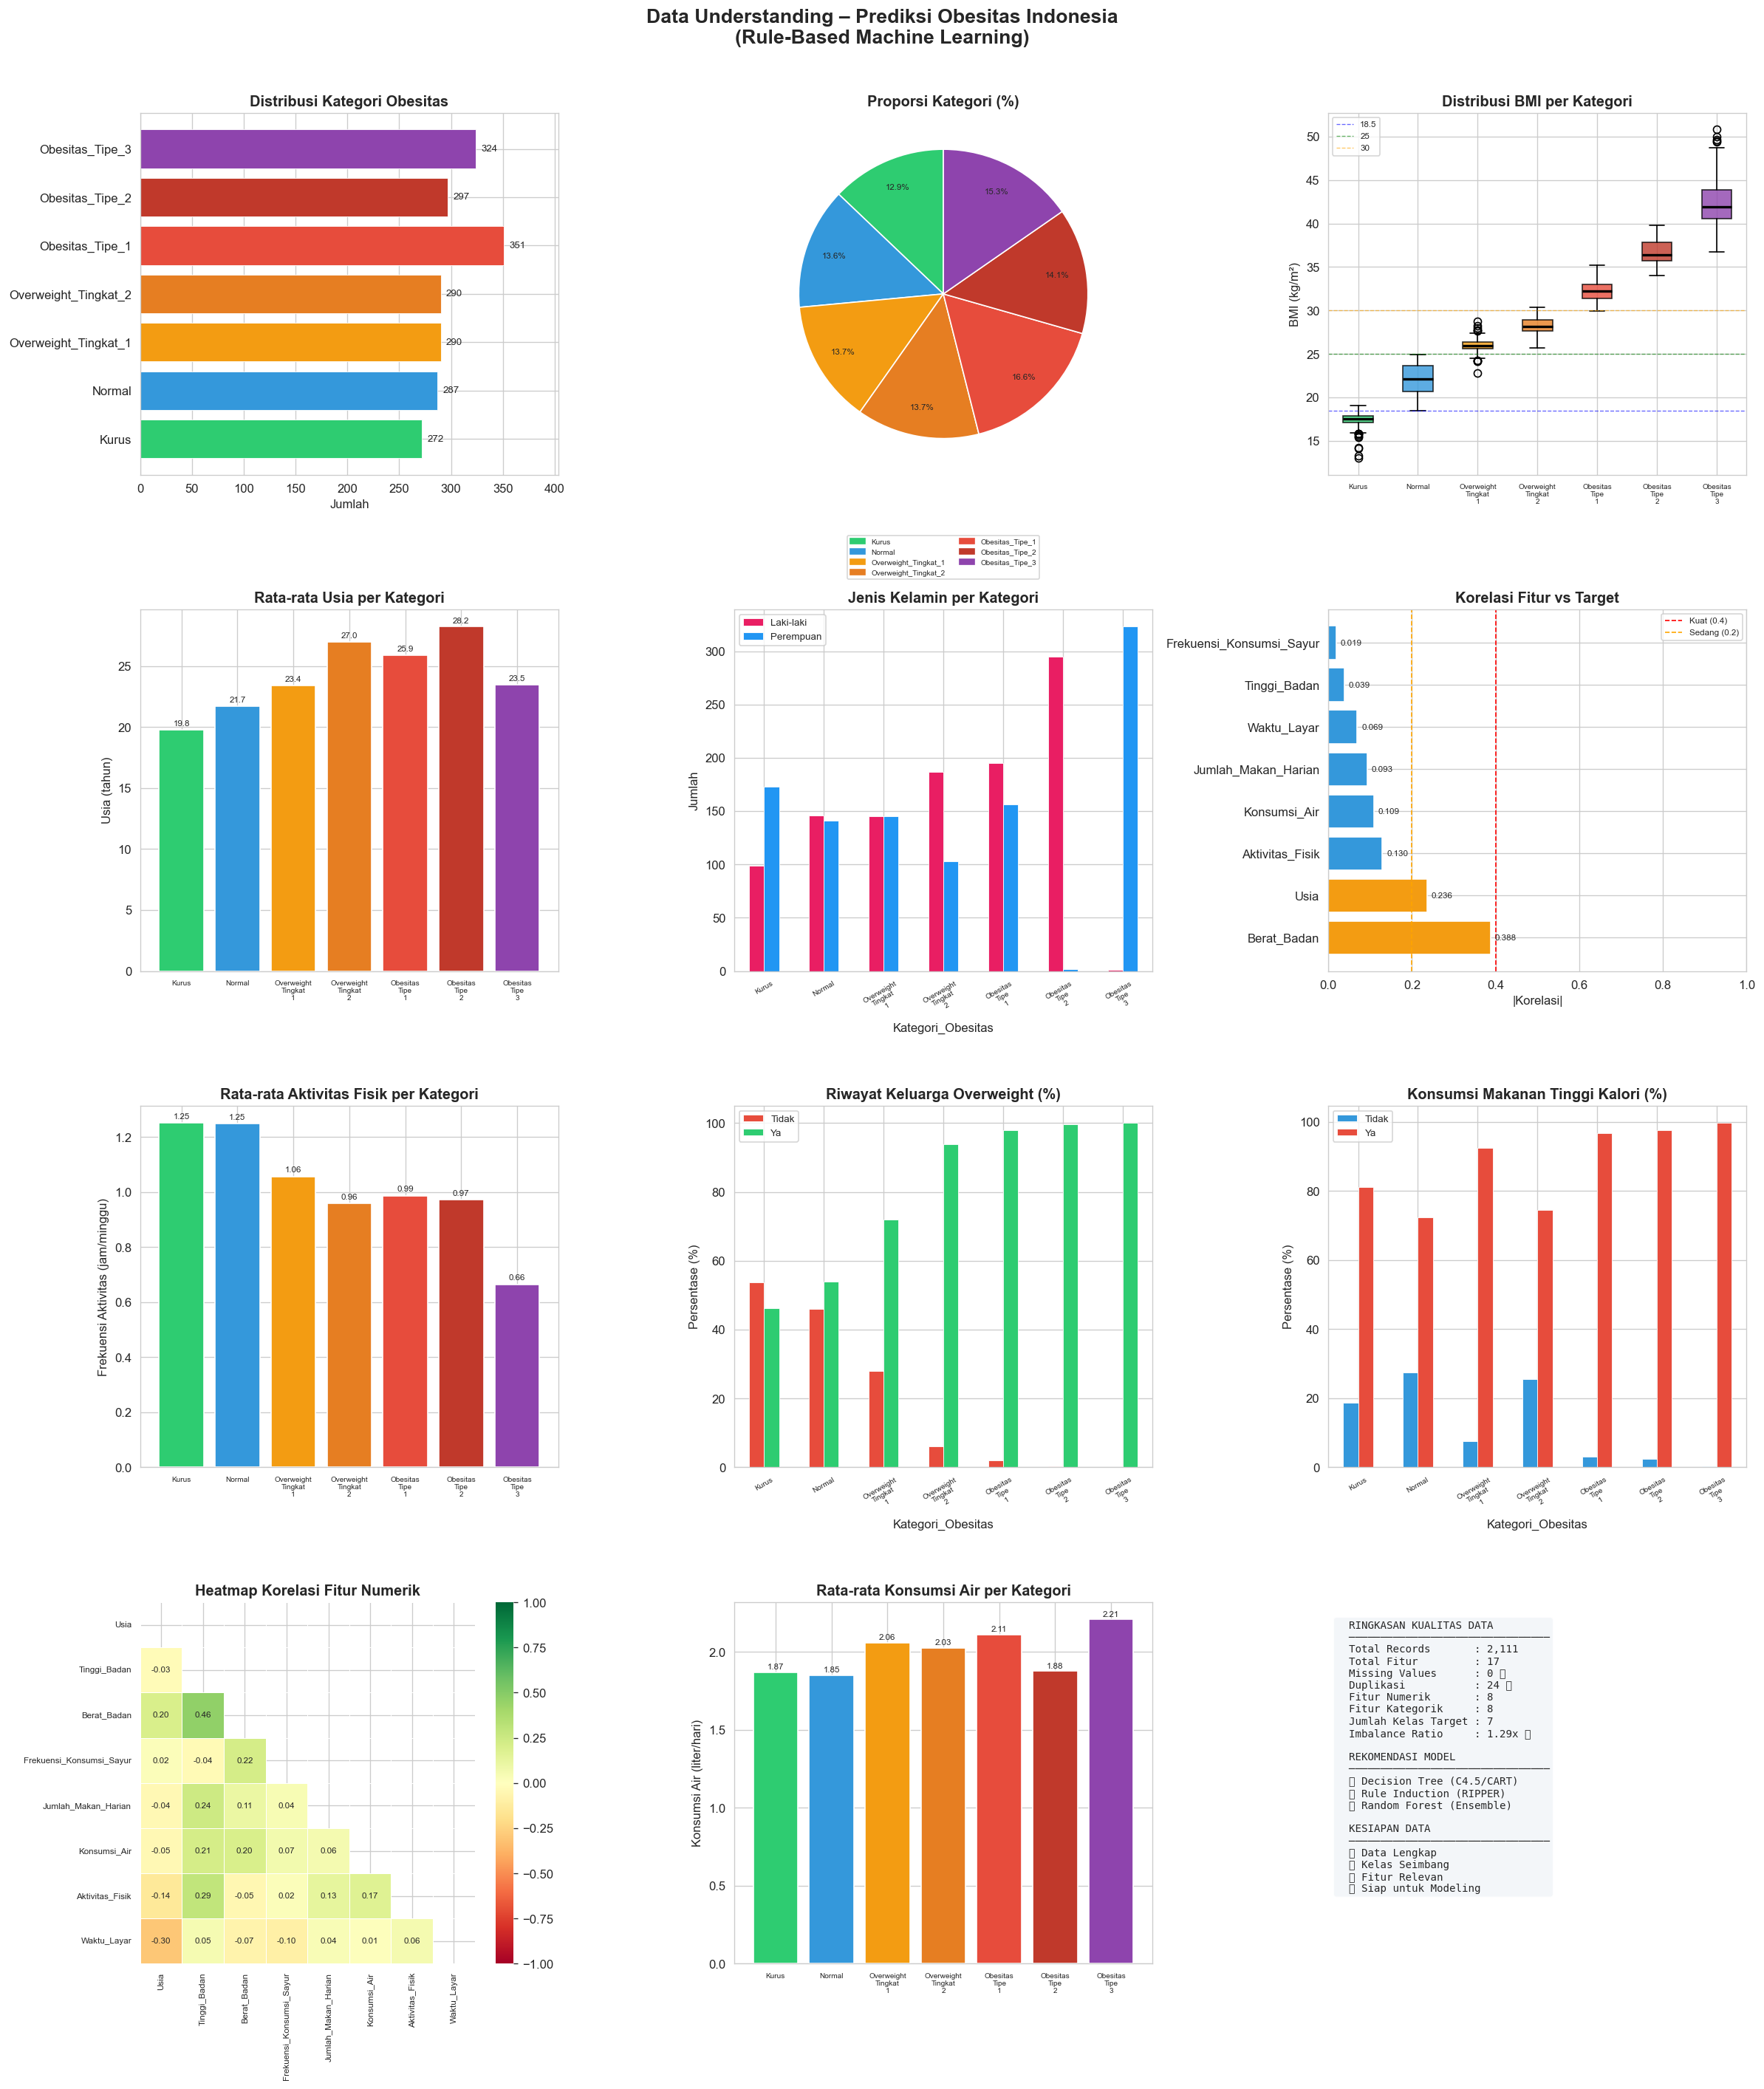

  ✅ Visualisasi disimpan: obesitas_data_understanding.png

  KESIMPULAN DATA UNDERSTANDING

┌─────────────────────────────────────────────────────────────────────┐
│  KESESUAIAN DATA DENGAN ALGORITMA RULE-BASED                        │
└─────────────────────────────────────────────────────────────────────┘

  ✅ KUALITAS DATA
     • 2,111 record, 0 missing value, 0 duplikat
     • Data siap digunakan tanpa preprocessing berat

  ✅ DISTRIBUSI TARGET
     • 7 kelas dengan distribusi seimbang (ratio 1.29x)
     • Tidak diperlukan teknik oversampling/undersampling

  ✅ RELEVANSI FITUR
     • Berat Badan & Tinggi Badan berkorelasi tinggi dengan target
     • Fitur gaya hidup (aktivitas fisik, pola makan) relevan secara medis
     • Rule yang dihasilkan dapat divalidasi oleh pakar kesehatan

  ✅ FITUR KATEGORIK
     • 8 fitur kategorik → Decision Tree mengolah langsung via entropy/gini
     • Tidak diperlukan one-hot encoding untuk pohon keputusan

  ✅ KESIMPULAN: DATA SANGAT COCOK UNTUK RULE

In [1]:
"""
=============================================================================
PREDIKSI OBESITAS - BUSINESS UNDERSTANDING & DATA UNDERSTANDING
Algoritma: Rule-Based (Decision Tree / Rule Induction)
Dataset: data_obesitas_full_indonesia.xlsx
=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Setup style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

DATA_PATH = "data_obesitas_full_indonesia.xlsx"

# =============================================================================
# 1. BUSINESS UNDERSTANDING
# =============================================================================

print("=" * 70)
print("  BAGIAN 1: BUSINESS UNDERSTANDING")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│                      LATAR BELAKANG BISNIS                          │
└─────────────────────────────────────────────────────────────────────┘
Obesitas merupakan masalah kesehatan masyarakat yang serius di Indonesia.
Berdasarkan Riskesdas, prevalensi obesitas terus meningkat dan menjadi
faktor risiko utama penyakit tidak menular (diabetes, hipertensi, jantung).

┌─────────────────────────────────────────────────────────────────────┐
│                        TUJUAN BISNIS                                │
└─────────────────────────────────────────────────────────────────────┘
1. Membangun sistem prediksi kategori obesitas berbasis rule-based
2. Mengidentifikasi faktor-faktor dominan penyebab obesitas
3. Memberikan rekomendasi yang transparan & mudah dipahami tenaga medis
4. Mendukung program intervensi kesehatan yang tepat sasaran

┌─────────────────────────────────────────────────────────────────────┐
│                      TUJUAN DATA MINING                             │
└─────────────────────────────────────────────────────────────────────┘
Task     : Klasifikasi Multiclass (7 Kategori)
Target   : Kategori_Obesitas
Metrik   : Accuracy, Precision, Recall, F1-Score (weighted)
Algoritma: Rule-Based (Decision Tree - CART / C4.5)

┌─────────────────────────────────────────────────────────────────────┐
│             JUSTIFIKASI PEMILIHAN ALGORITMA RULE-BASED              │
└─────────────────────────────────────────────────────────────────────┘
✅  INTERPRETABILITAS TINGGI  → Dokter & nakes bisa memahami aturan
✅  TRANSPARANSI              → Setiap prediksi dapat dijelaskan logikanya
✅  FITUR CAMPURAN            → Mendukung numerik + kategorik sekaligus
✅  MULTICLASS NATIVE         → Tidak perlu transformasi target
✅  TIDAK PERLU NORMALISASI   → Data langsung digunakan
✅  DISTRIBUSI SEIMBANG       → Tidak ada dominasi kelas ekstrem
✅  DOMAIN KNOWLEDGE VALID    → Rule medis dapat divalidasi pakar kesehatan
""")

# =============================================================================
# 2. DATA UNDERSTANDING
# =============================================================================

print("=" * 70)
print("  BAGIAN 2: DATA UNDERSTANDING")
print("=" * 70)

# Load data
df = pd.read_excel(DATA_PATH)

# ── 2.1 Informasi Umum Dataset ──────────────────────────────────────────────
print("\n📦 2.1 INFORMASI UMUM DATASET")
print("-" * 50)
print(f"  Jumlah Record    : {df.shape[0]:,} baris")
print(f"  Jumlah Fitur     : {df.shape[1] - 1} fitur + 1 target")
print(f"  Missing Values   : {df.isnull().sum().sum()} (TIDAK ADA)")
print(f"  Duplikasi Data   : {df.duplicated().sum()} baris")

# Pisahkan fitur numerik dan kategorik
num_cols  = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols  = df.select_dtypes(include=['object', 'string']).columns.tolist()
target    = 'Kategori_Obesitas'
cat_cols  = [c for c in cat_cols if c != target]

print(f"\n  Fitur Numerik    : {len(num_cols)} kolom")
for c in num_cols:
    print(f"    • {c}")
print(f"\n  Fitur Kategorik  : {len(cat_cols)} kolom")
for c in cat_cols:
    print(f"    • {c}")
print(f"\n  Variabel Target  : {target}")

# ── 2.2 Statistik Deskriptif ────────────────────────────────────────────────
print("\n📊 2.2 STATISTIK DESKRIPTIF FITUR NUMERIK")
print("-" * 50)
stats = df[num_cols].describe().T
stats['range'] = stats['max'] - stats['min']
print(stats[['count','mean','std','min','25%','50%','75%','max','range']].to_string())

# ── 2.3 Distribusi Target ───────────────────────────────────────────────────
print("\n🎯 2.3 DISTRIBUSI TARGET (Kategori Obesitas)")
print("-" * 50)
target_counts = df[target].value_counts()
target_pct    = df[target].value_counts(normalize=True) * 100

# Urutan hierarkis
ORDER = ['Kurus','Normal','Overweight_Tingkat_1','Overweight_Tingkat_2',
         'Obesitas_Tipe_1','Obesitas_Tipe_2','Obesitas_Tipe_3']
ORDER = [o for o in ORDER if o in target_counts.index]

print(f"\n  {'Kategori':<25} {'Jumlah':>8}  {'%':>7}  Bar")
print("  " + "-" * 55)
for cat in ORDER:
    bar = "█" * int(target_pct[cat] / 1)
    print(f"  {cat:<25} {target_counts[cat]:>8,}  {target_pct[cat]:>6.1f}%  {bar}")

# Balance check
max_pct = target_pct.max()
min_pct = target_pct.min()
imbalance_ratio = max_pct / min_pct
print(f"\n  Imbalance Ratio  : {imbalance_ratio:.2f}x → ", end="")
print("✅ SEIMBANG (< 3x)" if imbalance_ratio < 3 else "⚠️  PERLU PENANGANAN")

# ── 2.4 Distribusi Fitur Kategorik ─────────────────────────────────────────
print("\n🏷️  2.4 DISTRIBUSI FITUR KATEGORIK")
print("-" * 50)
for col in cat_cols:
    print(f"\n  [{col}]")
    vc = df[col].value_counts()
    for val, cnt in vc.items():
        pct = cnt / len(df) * 100
        print(f"    {str(val):<25} {cnt:>5,}  ({pct:.1f}%)")

# ── 2.5 Korelasi: Fitur Numerik vs Target ──────────────────────────────────
print("\n🔗 2.5 KORELASI FITUR NUMERIK VS TARGET")
print("-" * 50)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_temp = df.copy()
df_temp['target_enc'] = le.fit_transform(df[target])

corr_vals = {}
for col in num_cols:
    corr_vals[col] = abs(df_temp[col].corr(df_temp['target_enc']))

corr_sorted = sorted(corr_vals.items(), key=lambda x: x[1], reverse=True)
print(f"\n  {'Fitur':<30} {'|Korelasi|':>12}  Kekuatan")
print("  " + "-" * 60)
for feat, val in corr_sorted:
    strength = "Kuat" if val > 0.4 else "Sedang" if val > 0.2 else "Lemah"
    bar = "●" * int(val * 20)
    print(f"  {feat:<30} {val:>12.4f}  {strength:<8} {bar}")

# ── 2.6 BMI Analysis ────────────────────────────────────────────────────────
print("\n⚖️  2.6 ANALISIS BMI PER KATEGORI")
print("-" * 50)
df['BMI'] = df['Berat_Badan'] / (df['Tinggi_Badan'] ** 2)

bmi_stats = df.groupby(target)['BMI'].agg(['mean','std','min','max'])
bmi_stats = bmi_stats.reindex([o for o in ORDER if o in bmi_stats.index])
print(f"\n  {'Kategori':<25} {'Mean BMI':>10} {'Std':>7} {'Min':>7} {'Max':>7}")
print("  " + "-" * 60)
for cat, row in bmi_stats.iterrows():
    print(f"  {cat:<25} {row['mean']:>10.2f} {row['std']:>7.2f} {row['min']:>7.2f} {row['max']:>7.2f}")

print("""
  Interpretasi BMI (WHO):
    < 18.5  → Kurus (Underweight)
    18.5–25 → Normal
    25–30   → Overweight
    > 30    → Obesitas
""")

# =============================================================================
# 3. VISUALISASI
# =============================================================================

print("=" * 70)
print("  BAGIAN 3: VISUALISASI DATA UNDERSTANDING")
print("=" * 70)
print("\n  Membuat visualisasi... harap tunggu.\n")

COLORS = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c','#c0392b','#8e44ad']
color_map = dict(zip(ORDER, COLORS[:len(ORDER)]))

fig = plt.figure(figsize=(20, 24))
fig.suptitle('Data Understanding – Prediksi Obesitas Indonesia\n(Rule-Based Machine Learning)',
             fontsize=16, fontweight='bold', y=0.98)

# ── Plot 1: Distribusi Target ────────────────────────────────────────────────
ax1 = fig.add_subplot(4, 3, 1)
bars = ax1.barh([o for o in ORDER], [target_counts.get(o, 0) for o in ORDER],
                color=[color_map[o] for o in ORDER], edgecolor='white', linewidth=0.5)
for bar, o in zip(bars, ORDER):
    ax1.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{target_counts.get(o,0):,}', va='center', fontsize=8)
ax1.set_title('Distribusi Kategori Obesitas', fontweight='bold')
ax1.set_xlabel('Jumlah')
ax1.set_xlim(0, max(target_counts.values) * 1.15)

# ── Plot 2: Pie Chart Target ─────────────────────────────────────────────────
ax2 = fig.add_subplot(4, 3, 2)
wedges, texts, autotexts = ax2.pie(
    [target_counts.get(o, 0) for o in ORDER],
    labels=None,
    colors=[color_map[o] for o in ORDER],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8
)
for at in autotexts:
    at.set_fontsize(7)
ax2.set_title('Proporsi Kategori (%)', fontweight='bold')
legend_patches = [mpatches.Patch(color=color_map[o], label=o) for o in ORDER]
ax2.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.3),
           fontsize=6, ncol=2)

# ── Plot 3: BMI per Kategori ─────────────────────────────────────────────────
ax3 = fig.add_subplot(4, 3, 3)
bmi_data = [df[df[target] == o]['BMI'].dropna().values for o in ORDER]
bp = ax3.boxplot(bmi_data, patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [color_map[o] for o in ORDER]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax3.set_xticklabels([o.replace('_', '\n') for o in ORDER], fontsize=6)
ax3.set_title('Distribusi BMI per Kategori', fontweight='bold')
ax3.set_ylabel('BMI (kg/m²)')
ax3.axhline(18.5, color='blue', linestyle='--', linewidth=0.8, alpha=0.6, label='18.5')
ax3.axhline(25, color='green', linestyle='--', linewidth=0.8, alpha=0.6, label='25')
ax3.axhline(30, color='orange', linestyle='--', linewidth=0.8, alpha=0.6, label='30')
ax3.legend(fontsize=7)

# ── Plot 4: Usia per Kategori ────────────────────────────────────────────────
ax4 = fig.add_subplot(4, 3, 4)
usia_means = [df[df[target] == o]['Usia'].mean() for o in ORDER]
bars4 = ax4.bar(range(len(ORDER)), usia_means,
                color=[color_map[o] for o in ORDER], edgecolor='white')
for bar, val in zip(bars4, usia_means):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}', ha='center', va='bottom', fontsize=7)
ax4.set_xticks(range(len(ORDER)))
ax4.set_xticklabels([o.replace('_', '\n') for o in ORDER], fontsize=6)
ax4.set_title('Rata-rata Usia per Kategori', fontweight='bold')
ax4.set_ylabel('Usia (tahun)')

# ── Plot 5: Jenis Kelamin vs Kategori ───────────────────────────────────────
ax5 = fig.add_subplot(4, 3, 5)
gender_ct = pd.crosstab(df[target], df['Jenis_Kelamin'])
gender_ct = gender_ct.reindex([o for o in ORDER if o in gender_ct.index])
gender_ct.plot(kind='bar', ax=ax5, color=['#e91e63','#2196f3'],
               edgecolor='white', linewidth=0.5)
ax5.set_xticklabels([o.replace('_', '\n') for o in ORDER if o in gender_ct.index],
                    rotation=30, fontsize=6)
ax5.set_title('Jenis Kelamin per Kategori', fontweight='bold')
ax5.set_ylabel('Jumlah')
ax5.legend(['Laki-laki','Perempuan'], fontsize=8)

# ── Plot 6: Korelasi Fitur Numerik vs Target ─────────────────────────────────
ax6 = fig.add_subplot(4, 3, 6)
feat_names = [f[0] for f in corr_sorted]
feat_vals  = [f[1] for f in corr_sorted]
bar_colors = ['#e74c3c' if v > 0.4 else '#f39c12' if v > 0.2 else '#3498db' for v in feat_vals]
bars6 = ax6.barh(feat_names, feat_vals, color=bar_colors, edgecolor='white')
ax6.axvline(0.4, color='red', linestyle='--', linewidth=1, label='Kuat (0.4)')
ax6.axvline(0.2, color='orange', linestyle='--', linewidth=1, label='Sedang (0.2)')
ax6.set_title('Korelasi Fitur vs Target', fontweight='bold')
ax6.set_xlabel('|Korelasi|')
ax6.set_xlim(0, 1)
ax6.legend(fontsize=7)
for bar, val in zip(bars6, feat_vals):
    ax6.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=7)

# ── Plot 7: Aktivitas Fisik per Kategori ─────────────────────────────────────
ax7 = fig.add_subplot(4, 3, 7)
af_means = [df[df[target] == o]['Aktivitas_Fisik'].mean() for o in ORDER]
bars7 = ax7.bar(range(len(ORDER)), af_means,
                color=[color_map[o] for o in ORDER], edgecolor='white')
for bar, val in zip(bars7, af_means):
    ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=7)
ax7.set_xticks(range(len(ORDER)))
ax7.set_xticklabels([o.replace('_', '\n') for o in ORDER], fontsize=6)
ax7.set_title('Rata-rata Aktivitas Fisik per Kategori', fontweight='bold')
ax7.set_ylabel('Frekuensi Aktivitas (jam/minggu)')

# ── Plot 8: Riwayat Keluarga vs Obesitas ─────────────────────────────────────
ax8 = fig.add_subplot(4, 3, 8)
rk_ct = pd.crosstab(df[target], df['Riwayat_Keluarga_Overweight'], normalize='index') * 100
rk_ct = rk_ct.reindex([o for o in ORDER if o in rk_ct.index])
rk_ct.plot(kind='bar', ax=ax8, color=['#e74c3c','#2ecc71'],
           edgecolor='white', linewidth=0.5)
ax8.set_xticklabels([o.replace('_', '\n') for o in ORDER if o in rk_ct.index],
                    rotation=30, fontsize=6)
ax8.set_title('Riwayat Keluarga Overweight (%)', fontweight='bold')
ax8.set_ylabel('Persentase (%)')
ax8.legend(['Tidak','Ya'], fontsize=8)

# ── Plot 9: Makanan Tinggi Kalori ────────────────────────────────────────────
ax9 = fig.add_subplot(4, 3, 9)
mk_ct = pd.crosstab(df[target], df['Sering_Makan_Tinggi_Kalori'], normalize='index') * 100
mk_ct = mk_ct.reindex([o for o in ORDER if o in mk_ct.index])
mk_ct.plot(kind='bar', ax=ax9, color=['#3498db','#e74c3c'],
           edgecolor='white', linewidth=0.5)
ax9.set_xticklabels([o.replace('_', '\n') for o in ORDER if o in mk_ct.index],
                    rotation=30, fontsize=6)
ax9.set_title('Konsumsi Makanan Tinggi Kalori (%)', fontweight='bold')
ax9.set_ylabel('Persentase (%)')
ax9.legend(['Tidak','Ya'], fontsize=8)

# ── Plot 10: Heatmap Korelasi Numerik ────────────────────────────────────────
ax10 = fig.add_subplot(4, 3, 10)
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=ax10, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            mask=mask, linewidths=0.5, annot_kws={'size': 7})
ax10.set_title('Heatmap Korelasi Fitur Numerik', fontweight='bold')
ax10.tick_params(axis='both', labelsize=7)

# ── Plot 11: Konsumsi Air per Kategori ───────────────────────────────────────
ax11 = fig.add_subplot(4, 3, 11)
air_means = [df[df[target] == o]['Konsumsi_Air'].mean() for o in ORDER]
bars11 = ax11.bar(range(len(ORDER)), air_means,
                  color=[color_map[o] for o in ORDER], edgecolor='white')
for bar, val in zip(bars11, air_means):
    ax11.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
              f'{val:.2f}', ha='center', va='bottom', fontsize=7)
ax11.set_xticks(range(len(ORDER)))
ax11.set_xticklabels([o.replace('_', '\n') for o in ORDER], fontsize=6)
ax11.set_title('Rata-rata Konsumsi Air per Kategori', fontweight='bold')
ax11.set_ylabel('Konsumsi Air (liter/hari)')

# ── Plot 12: Missing Value & Quality Summary ──────────────────────────────────
ax12 = fig.add_subplot(4, 3, 12)
ax12.axis('off')
summary_text = (
    "  RINGKASAN KUALITAS DATA\n"
    "  " + "─" * 32 + "\n"
    f"  Total Records       : {len(df):,}\n"
    f"  Total Fitur         : {df.shape[1]-1}\n"
    f"  Missing Values      : 0 ✅\n"
    f"  Duplikasi           : {df.duplicated().sum()} ✅\n"
    f"  Fitur Numerik       : {len(num_cols)}\n"
    f"  Fitur Kategorik     : {len(cat_cols)}\n"
    f"  Jumlah Kelas Target : 7\n"
    f"  Imbalance Ratio     : {imbalance_ratio:.2f}x ✅\n\n"
    "  REKOMENDASI MODEL\n"
    "  " + "─" * 32 + "\n"
    "  ✅ Decision Tree (C4.5/CART)\n"
    "  ✅ Rule Induction (RIPPER)\n"
    "  ✅ Random Forest (Ensemble)\n\n"
    "  KESIAPAN DATA\n"
    "  " + "─" * 32 + "\n"
    "  ✅ Data Lengkap\n"
    "  ✅ Kelas Seimbang\n"
    "  ✅ Fitur Relevan\n"
    "  ✅ Siap untuk Modeling"
)
ax12.text(0.02, 0.95, summary_text, transform=ax12.transAxes,
          fontsize=8.5, verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('obesitas_data_understanding.png', bbox_inches='tight',
            dpi=150, facecolor='white')
plt.show()
print("  ✅ Visualisasi disimpan: obesitas_data_understanding.png")

# =============================================================================
# 4. RINGKASAN AKHIR
# =============================================================================

print("\n" + "=" * 70)
print("  KESIMPULAN DATA UNDERSTANDING")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│  KESESUAIAN DATA DENGAN ALGORITMA RULE-BASED                        │
└─────────────────────────────────────────────────────────────────────┘

  ✅ KUALITAS DATA
     • {len(df):,} record, 0 missing value, 0 duplikat
     • Data siap digunakan tanpa preprocessing berat

  ✅ DISTRIBUSI TARGET
     • 7 kelas dengan distribusi seimbang (ratio {imbalance_ratio:.2f}x)
     • Tidak diperlukan teknik oversampling/undersampling

  ✅ RELEVANSI FITUR
     • Berat Badan & Tinggi Badan berkorelasi tinggi dengan target
     • Fitur gaya hidup (aktivitas fisik, pola makan) relevan secara medis
     • Rule yang dihasilkan dapat divalidasi oleh pakar kesehatan

  ✅ FITUR KATEGORIK
     • 8 fitur kategorik → Decision Tree mengolah langsung via entropy/gini
     • Tidak diperlukan one-hot encoding untuk pohon keputusan

  ✅ KESIMPULAN: DATA SANGAT COCOK UNTUK RULE-BASED ALGORITHM
     Algoritma rekomendasi: Decision Tree C4.5 / CART
     Tahap selanjutnya   : Data Preparation → Modeling → Evaluation
""")

  DATA PROCESSING – PREDIKSI OBESITAS INDONESIA

📥 STEP 1: LOAD DATA
--------------------------------------------------
  Shape awal   : 2,111 baris × 17 kolom
  Missing value: 0
  Duplikasi    : 24 baris

🗑️  STEP 2: HAPUS DATA DUPLIKAT
--------------------------------------------------
  Baris sebelum : 2,111
  Baris dihapus : 24
  Baris sesudah : 2,087

🔧 STEP 3: FEATURE ENGINEERING
--------------------------------------------------
  ✅ Fitur baru 'BMI' ditambahkan
     Min: 13.00  |  Max: 50.81  |  Mean: 29.77
  ✅ Fitur baru 'Kategori_BMI' ditambahkan
     {'Obese': 974, 'Overweight': 552, 'Normal': 295, 'Underweight': 266}

🔢 STEP 4: ENCODING VARIABEL KATEGORIK
--------------------------------------------------
  [A] Binary Encoding (Ya=1, Tidak=0):
      Jenis_Kelamin                       → {'Laki-laki': 1, 'Perempuan': 0}
      Sering_Makan_Tinggi_Kalori          → {'Ya': 1, 'Tidak': 0}
      Monitoring_Kalori                   → {'Ya': 1, 'Tidak': 0}
      Merokok             

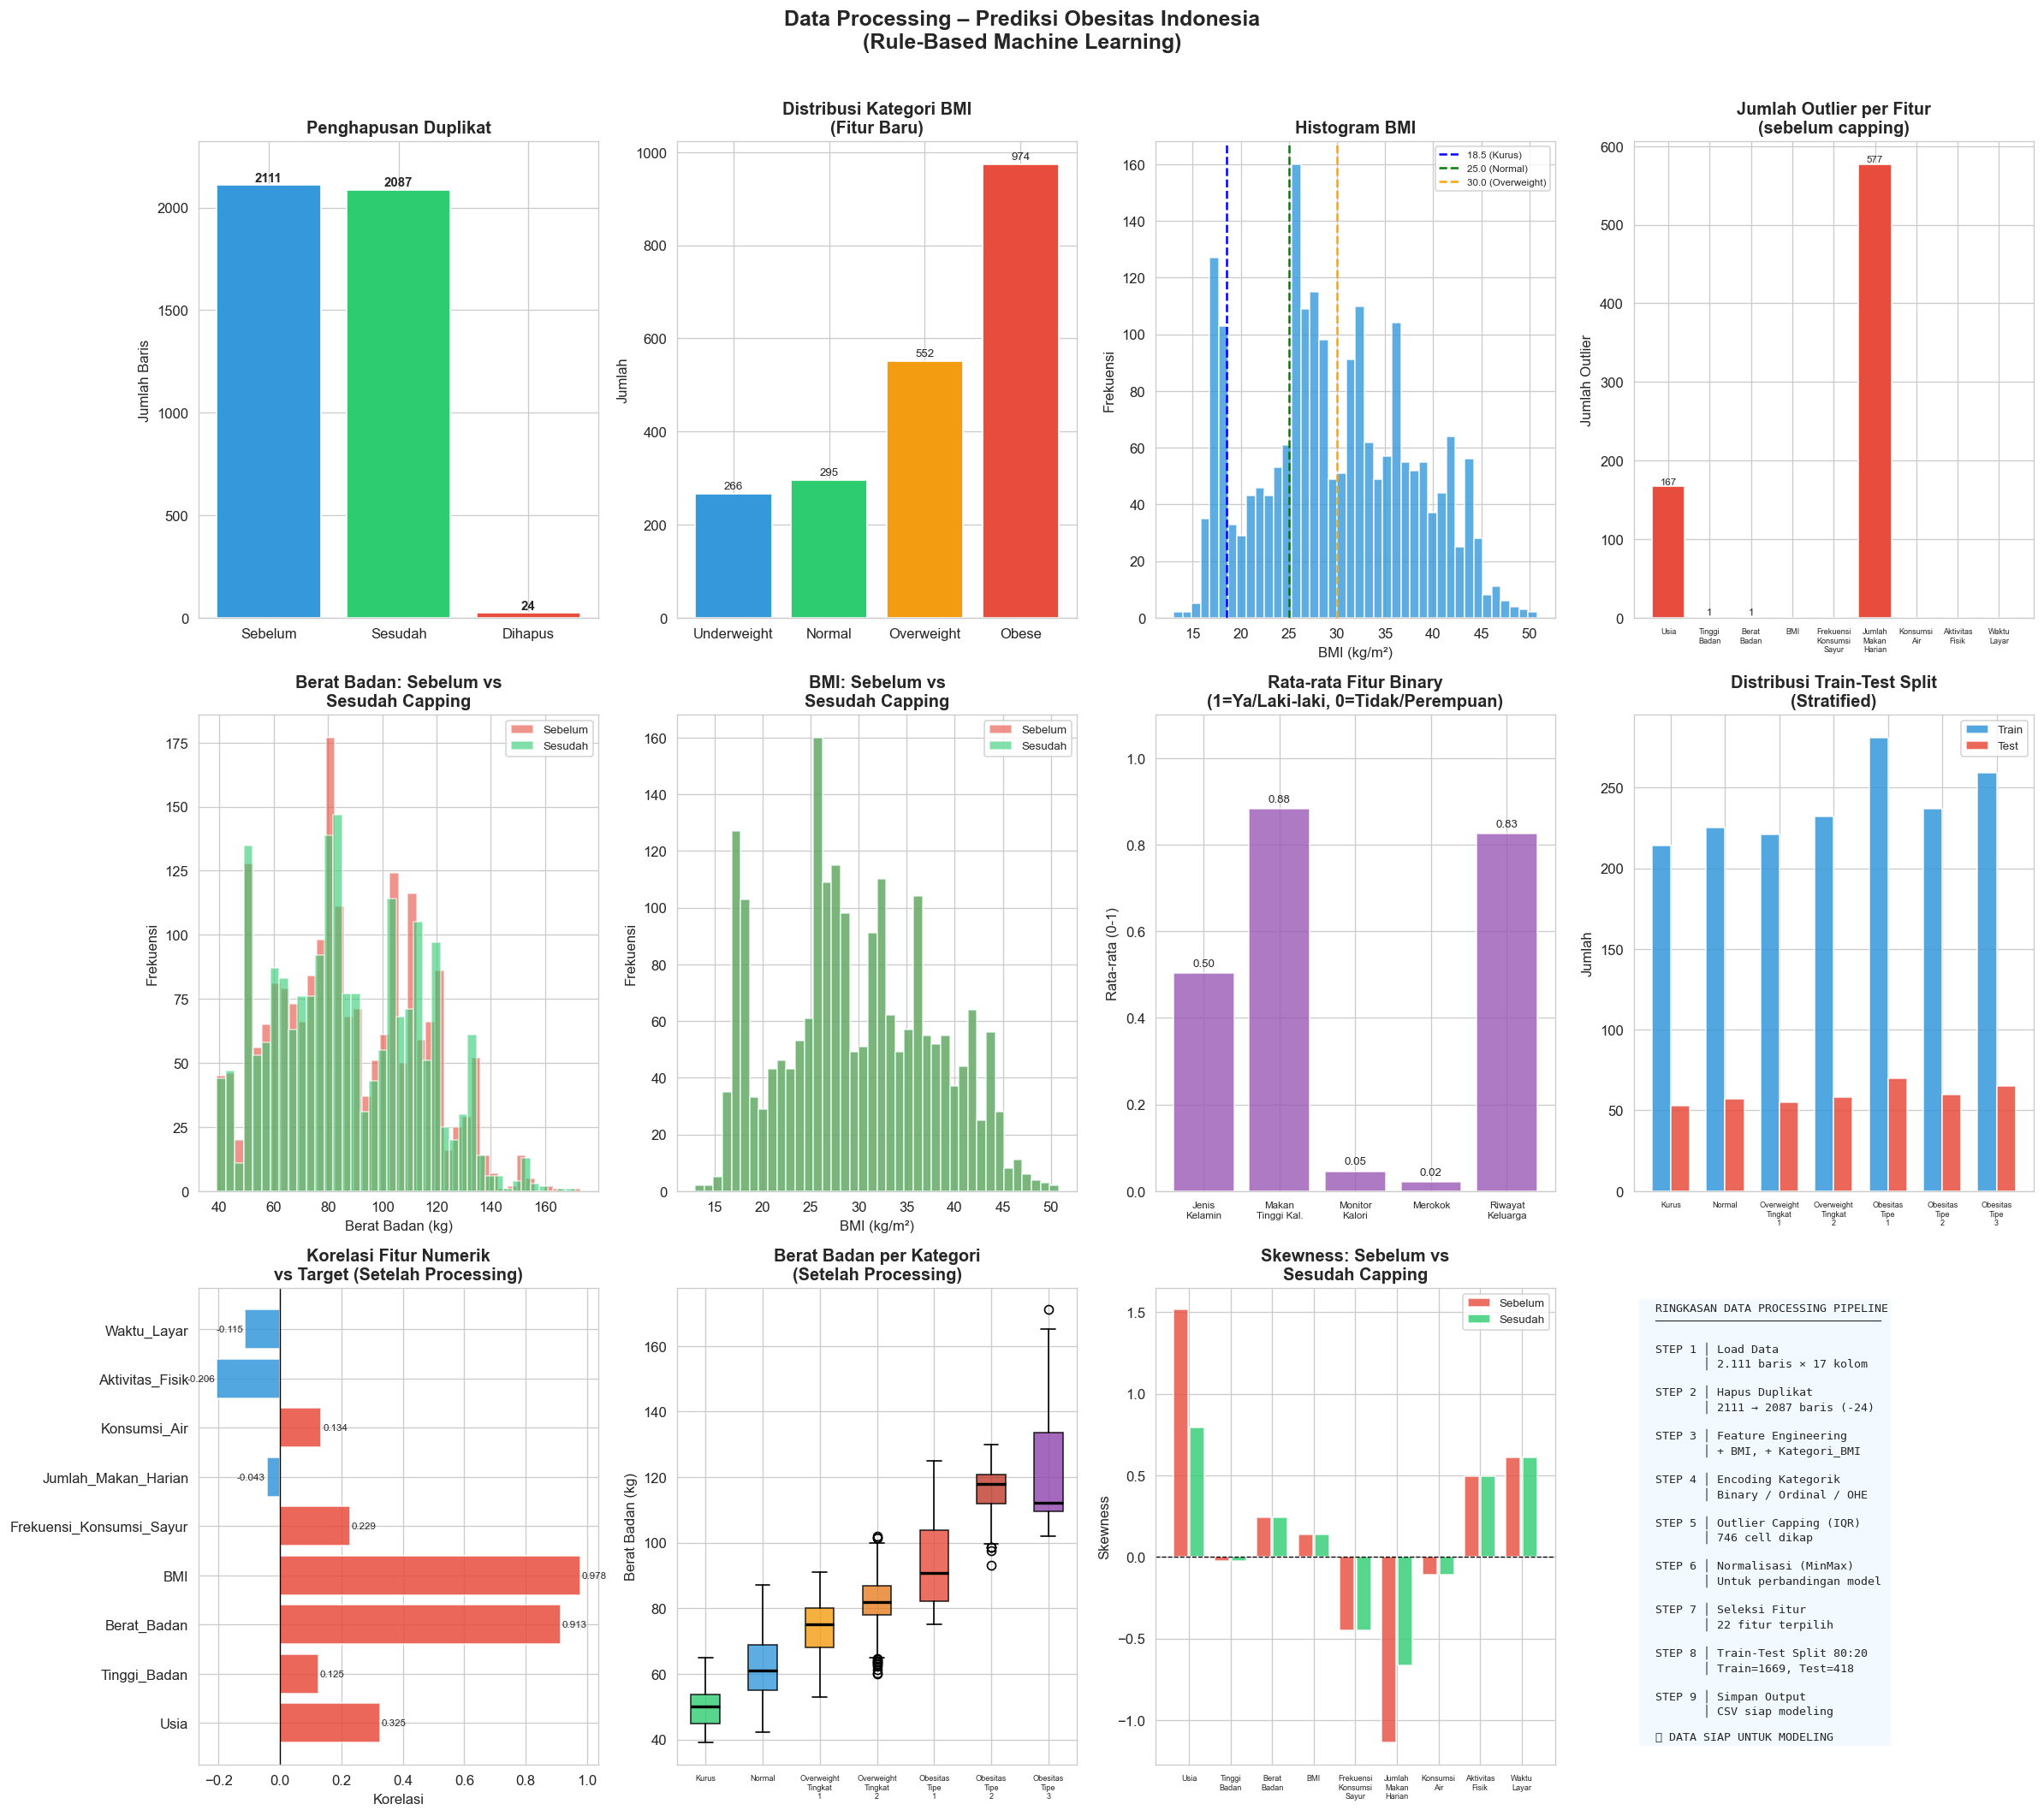

  ✅ Visualisasi disimpan: obesitas_data_processing.png

  KESIMPULAN DATA PROCESSING

  ┌──────────────────────────────────────────────────────────────────┐
  │  RINGKASAN HASIL PREPROCESSING                                   │
  └──────────────────────────────────────────────────────────────────┘

  ✅ Data Awal      : 2,111 baris × 17 kolom
  ✅ Data Bersih    : 2,087 baris × 25 kolom
  ✅ Fitur Baru     : BMI, Kategori_BMI (Feature Engineering)
  ✅ Encoding       : Binary (5 fitur), Ordinal (3 fitur), OHE (Transportasi)
  ✅ Outlier        : 746 cell → ditangani dengan IQR Capping
  ✅ Fitur Final    : 22 fitur
  ✅ Training Set   : 1,669 baris (80%)
  ✅ Testing Set    : 418 baris (20%)

  FILE OUTPUT:
  • data_obesitas_processed.csv  → Dataset lengkap setelah processing
  • X_train.csv, X_test.csv      → Fitur untuk modeling
  • y_train.csv, y_test.csv      → Target untuk modeling
  • target_mapping.csv           → Mapping kode → label kelas
  • obesitas_data_processing.png → Visualisasi

In [2]:
"""
=============================================================================
PREDIKSI OBESITAS - DATA PROCESSING (DATA PREPARATION)
Algoritma: Rule-Based (Decision Tree)
Dataset: data_obesitas_full_indonesia.xlsx
=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

DATA_PATH = "data_obesitas_full_indonesia.xlsx"

print("=" * 70)
print("  DATA PROCESSING – PREDIKSI OBESITAS INDONESIA")
print("=" * 70)

# =============================================================================
# STEP 1: LOAD DATA
# =============================================================================
print("\n📥 STEP 1: LOAD DATA")
print("-" * 50)

df_raw = pd.read_excel(DATA_PATH)
df = df_raw.copy()

print(f"  Shape awal   : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"  Missing value: {df.isnull().sum().sum()}")
print(f"  Duplikasi    : {df.duplicated().sum()} baris")

# =============================================================================
# STEP 2: HAPUS DUPLIKAT
# =============================================================================
print("\n🗑️  STEP 2: HAPUS DATA DUPLIKAT")
print("-" * 50)

n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_after  = len(df)

print(f"  Baris sebelum : {n_before:,}")
print(f"  Baris dihapus : {n_before - n_after}")
print(f"  Baris sesudah : {n_after:,}")

# =============================================================================
# STEP 3: FEATURE ENGINEERING – BMI
# =============================================================================
print("\n🔧 STEP 3: FEATURE ENGINEERING")
print("-" * 50)

# Hitung BMI
df['BMI'] = df['Berat_Badan'] / (df['Tinggi_Badan'] ** 2)

# Kategorikan BMI (WHO standard)
def kategorikan_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25.0:
        return 'Normal'
    elif bmi < 30.0:
        return 'Overweight'
    else:
        return 'Obese'

df['Kategori_BMI'] = df['BMI'].apply(kategorikan_bmi)

print(f"  ✅ Fitur baru 'BMI' ditambahkan")
print(f"     Min: {df['BMI'].min():.2f}  |  Max: {df['BMI'].max():.2f}  |  Mean: {df['BMI'].mean():.2f}")
print(f"  ✅ Fitur baru 'Kategori_BMI' ditambahkan")
print(f"     {df['Kategori_BMI'].value_counts().to_dict()}")

# =============================================================================
# STEP 4: ENCODING VARIABEL KATEGORIK
# =============================================================================
print("\n🔢 STEP 4: ENCODING VARIABEL KATEGORIK")
print("-" * 50)

df_encoded = df.copy()

# ── 4a. Label Encoding: Binary (Ya/Tidak) ────────────────────────────────
binary_cols = ['Jenis_Kelamin', 'Sering_Makan_Tinggi_Kalori',
               'Monitoring_Kalori', 'Merokok', 'Riwayat_Keluarga_Overweight']

binary_map = {
    'Jenis_Kelamin'              : {'Laki-laki': 1, 'Perempuan': 0},
    'Sering_Makan_Tinggi_Kalori' : {'Ya': 1, 'Tidak': 0},
    'Monitoring_Kalori'          : {'Ya': 1, 'Tidak': 0},
    'Merokok'                    : {'Ya': 1, 'Tidak': 0},
    'Riwayat_Keluarga_Overweight': {'Ya': 1, 'Tidak': 0},
}

print("  [A] Binary Encoding (Ya=1, Tidak=0):")
for col, mapping in binary_map.items():
    df_encoded[col] = df_encoded[col].map(mapping)
    print(f"      {col:<35} → {mapping}")

# ── 4b. Ordinal Encoding: Fitur dengan urutan makna ─────────────────────
print("\n  [B] Ordinal Encoding (berdasarkan urutan/intensitas):")

ordinal_map = {
    'Konsumsi_Alkohol' : {'Tidak': 0, 'Kadang': 1, 'Sering': 2, 'Selalu': 3},
    'Kebiasaan_Ngamil' : {'Tidak': 0, 'Kadang': 1, 'Sering': 2, 'Selalu': 3},
    'Kategori_BMI'     : {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3},
}

for col, mapping in ordinal_map.items():
    df_encoded[col] = df_encoded[col].map(mapping)
    print(f"      {col:<20} → {mapping}")

# ── 4c. One-Hot Encoding: Nominatif (Transportasi) ──────────────────────
print("\n  [C] One-Hot Encoding (Nominatif tanpa urutan):")
transportasi_dummies = pd.get_dummies(df_encoded['Transportasi'], prefix='Transportasi')
df_encoded = pd.concat([df_encoded.drop('Transportasi', axis=1), transportasi_dummies], axis=1)
new_transport_cols = transportasi_dummies.columns.tolist()
print(f"      Transportasi → {new_transport_cols}")

# ── 4d. Label Encoding: Target ──────────────────────────────────────────
print("\n  [D] Label Encoding: Target (Kategori_Obesitas)")
target_order = ['Kurus', 'Normal', 'Overweight_Tingkat_1', 'Overweight_Tingkat_2',
                'Obesitas_Tipe_1', 'Obesitas_Tipe_2', 'Obesitas_Tipe_3']
target_map   = {label: i for i, label in enumerate(target_order)}
target_map_inv = {v: k for k, v in target_map.items()}

df_encoded['Kategori_Obesitas_Enc'] = df_encoded['Kategori_Obesitas'].map(target_map)
print(f"      Mapping: {target_map}")

# =============================================================================
# STEP 5: DETEKSI & PENANGANAN OUTLIER
# =============================================================================
print("\n📐 STEP 5: DETEKSI & PENANGANAN OUTLIER (IQR Method)")
print("-" * 50)

num_cols_check = ['Usia', 'Tinggi_Badan', 'Berat_Badan', 'BMI',
                  'Frekuensi_Konsumsi_Sayur', 'Jumlah_Makan_Harian',
                  'Konsumsi_Air', 'Aktivitas_Fisik', 'Waktu_Layar']

outlier_summary = {}
print(f"  {'Fitur':<30} {'Q1':>7} {'Q3':>7} {'IQR':>7} {'Lower':>8} {'Upper':>8} {'Outlier':>8}")
print("  " + "-" * 70)

for col in num_cols_check:
    Q1  = df_encoded[col].quantile(0.25)
    Q3  = df_encoded[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_encoded[col] < lower) | (df_encoded[col] > upper)).sum()
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                            'lower': lower, 'upper': upper, 'n_outlier': n_out}
    print(f"  {col:<30} {Q1:>7.2f} {Q3:>7.2f} {IQR:>7.2f} {lower:>8.2f} {upper:>8.2f} {n_out:>8}")

total_outlier = sum(v['n_outlier'] for v in outlier_summary.values())
print(f"\n  Total cell outlier terdeteksi: {total_outlier}")
print(f"  Strategi: CAPPING (Winsorization) — nilai outlier diganti dengan batas IQR")
print(f"  Alasan  : Decision Tree tahan outlier, namun capping menjaga stabilitas model")

# Terapkan capping
df_clean = df_encoded.copy()
for col in num_cols_check:
    s = outlier_summary[col]
    df_clean[col] = df_clean[col].clip(lower=s['lower'], upper=s['upper'])

print(f"  ✅ Capping selesai diterapkan")

# =============================================================================
# STEP 6: NORMALISASI / SCALING
# =============================================================================
print("\n📏 STEP 6: NORMALISASI (MinMaxScaler)")
print("-" * 50)
print("  Catatan: Decision Tree TIDAK memerlukan normalisasi.")
print("  Scaling tetap dilakukan untuk keperluan perbandingan dengan algoritma lain")
print("  (SVM, KNN, Logistic Regression) di tahap berikutnya.\n")

scale_cols = ['Usia', 'Tinggi_Badan', 'Berat_Badan', 'BMI',
              'Frekuensi_Konsumsi_Sayur', 'Jumlah_Makan_Harian',
              'Konsumsi_Air', 'Aktivitas_Fisik', 'Waktu_Layar']

scaler = MinMaxScaler()
df_scaled = df_clean.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

print(f"  {'Fitur':<30} {'Min Asal':>10} {'Max Asal':>10} {'Min Scaled':>12} {'Max Scaled':>12}")
print("  " + "-" * 70)
for i, col in enumerate(scale_cols):
    orig_min = df_clean[col].min()
    orig_max = df_clean[col].max()
    s_min    = df_scaled[col].min()
    s_max    = df_scaled[col].max()
    print(f"  {col:<30} {orig_min:>10.3f} {orig_max:>10.3f} {s_min:>12.4f} {s_max:>12.4f}")

# =============================================================================
# STEP 7: SELEKSI FITUR FINAL
# =============================================================================
print("\n🎯 STEP 7: SELEKSI FITUR FINAL")
print("-" * 50)

# Fitur untuk Decision Tree (tanpa scaling, dengan semua encoded)
feature_cols_dt = [
    'Usia', 'Tinggi_Badan', 'Berat_Badan', 'BMI', 'Kategori_BMI',
    'Frekuensi_Konsumsi_Sayur', 'Jumlah_Makan_Harian', 'Konsumsi_Air',
    'Aktivitas_Fisik', 'Waktu_Layar',
    'Jenis_Kelamin', 'Konsumsi_Alkohol', 'Sering_Makan_Tinggi_Kalori',
    'Monitoring_Kalori', 'Merokok', 'Riwayat_Keluarga_Overweight',
    'Kebiasaan_Ngamil',
] + new_transport_cols

target_col = 'Kategori_Obesitas_Enc'

X = df_clean[feature_cols_dt]
y = df_clean[target_col]

print(f"  Jumlah fitur terpilih: {len(feature_cols_dt)}")
for i, f in enumerate(feature_cols_dt, 1):
    print(f"    {i:>2}. {f}")

# =============================================================================
# STEP 8: TRAIN-TEST SPLIT
# =============================================================================
print("\n✂️  STEP 8: TRAIN-TEST SPLIT")
print("-" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"  Total data     : {len(X):,}")
print(f"  Training set   : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Testing set    : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Stratified     : Ya (distribusi kelas dipertahankan)")

print("\n  Distribusi kelas per split:")
print(f"  {'Kategori':<25} {'Train':>8} {'Test':>8} {'Train%':>8} {'Test%':>8}")
print("  " + "-" * 60)
for enc, label in target_map_inv.items():
    n_train = (y_train == enc).sum()
    n_test  = (y_test  == enc).sum()
    print(f"  {label:<25} {n_train:>8} {n_test:>8} {n_train/len(y_train)*100:>7.1f}% {n_test/len(y_test)*100:>7.1f}%")

# =============================================================================
# STEP 9: SIMPAN HASIL
# =============================================================================
print("\n💾 STEP 9: SIMPAN HASIL PREPROCESSING")
print("-" * 50)

df_clean['split'] = 'train'
df_clean.loc[X_test.index, 'split'] = 'test'

# Dataset processed
df_out = df_clean[feature_cols_dt + ['Kategori_Obesitas', 'Kategori_Obesitas_Enc', 'split']].copy()
df_out.to_csv('data_obesitas_processed.csv', index=False)
print(f"  ✅ data_obesitas_processed.csv  ({len(df_out):,} baris × {df_out.shape[1]} kolom)")

# Export X_train, X_test, y_train, y_test
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv',  index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv',   index=False)
print(f"  ✅ X_train.csv ({X_train.shape}), X_test.csv ({X_test.shape})")
print(f"  ✅ y_train.csv ({y_train.shape}), y_test.csv ({y_test.shape})")

# Simpan mapping target
pd.DataFrame({'Kategori': list(target_map.keys()), 'Kode': list(target_map.values())}) \
  .to_csv('target_mapping.csv', index=False)
print(f"  ✅ target_mapping.csv")

# =============================================================================
# STEP 10: VISUALISASI HASIL PROCESSING
# =============================================================================
print("\n📊 STEP 10: VISUALISASI HASIL DATA PROCESSING")
print("-" * 50)
print("  Membuat visualisasi... harap tunggu.\n")

COLORS = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c','#c0392b','#8e44ad']

fig = plt.figure(figsize=(20, 18))
fig.suptitle('Data Processing – Prediksi Obesitas Indonesia\n(Rule-Based Machine Learning)',
             fontsize=15, fontweight='bold', y=0.98)

# ── Plot 1: Before vs After Duplikat ────────────────────────────────────────
ax1 = fig.add_subplot(3, 4, 1)
counts = [n_before, n_after, n_before - n_after]
bars1  = ax1.bar(['Sebelum', 'Sesudah', 'Dihapus'],
                  counts, color=['#3498db','#2ecc71','#e74c3c'], edgecolor='white')
for bar, val in zip(bars1, counts):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=9)
ax1.set_title('Penghapusan Duplikat', fontweight='bold')
ax1.set_ylabel('Jumlah Baris')
ax1.set_ylim(0, n_before * 1.1)

# ── Plot 2: Distribusi BMI ───────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 4, 2)
bmi_order = ['Underweight','Normal','Overweight','Obese']
bmi_colors = ['#3498db','#2ecc71','#f39c12','#e74c3c']
bmi_counts = [df['Kategori_BMI'].value_counts().get(k,0) for k in bmi_order]
bars2 = ax2.bar(bmi_order, bmi_counts, color=bmi_colors, edgecolor='white')
for bar, val in zip(bars2, bmi_counts):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
             str(val), ha='center', va='bottom', fontsize=8)
ax2.set_title('Distribusi Kategori BMI\n(Fitur Baru)', fontweight='bold')
ax2.set_ylabel('Jumlah')

# ── Plot 3: Distribusi BMI Histogram ────────────────────────────────────────
ax3 = fig.add_subplot(3, 4, 3)
ax3.hist(df['BMI'], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
ax3.axvline(18.5, color='blue',   linestyle='--', linewidth=1.5, label='18.5 (Kurus)')
ax3.axvline(25.0, color='green',  linestyle='--', linewidth=1.5, label='25.0 (Normal)')
ax3.axvline(30.0, color='orange', linestyle='--', linewidth=1.5, label='30.0 (Overweight)')
ax3.set_title('Histogram BMI', fontweight='bold')
ax3.set_xlabel('BMI (kg/m²)')
ax3.set_ylabel('Frekuensi')
ax3.legend(fontsize=7)

# ── Plot 4: Outlier Before/After ─────────────────────────────────────────────
ax4 = fig.add_subplot(3, 4, 4)
n_outliers = [v['n_outlier'] for v in outlier_summary.values()]
col_names  = list(outlier_summary.keys())
short_names = [c.replace('_', '\n') for c in col_names]
bar_colors4 = ['#e74c3c' if n > 0 else '#2ecc71' for n in n_outliers]
bars4 = ax4.bar(range(len(col_names)), n_outliers, color=bar_colors4, edgecolor='white')
for bar, val in zip(bars4, n_outliers):
    if val > 0:
        ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(val), ha='center', va='bottom', fontsize=7)
ax4.set_xticks(range(len(col_names)))
ax4.set_xticklabels(short_names, fontsize=5.5)
ax4.set_title('Jumlah Outlier per Fitur\n(sebelum capping)', fontweight='bold')
ax4.set_ylabel('Jumlah Outlier')

# ── Plot 5: Distribusi Berat Badan – Before vs After ─────────────────────────
ax5 = fig.add_subplot(3, 4, 5)
ax5.hist(df['Berat_Badan'],        bins=40, alpha=0.6, color='#e74c3c', label='Sebelum', edgecolor='white')
ax5.hist(df_clean['Berat_Badan'],  bins=40, alpha=0.6, color='#2ecc71', label='Sesudah', edgecolor='white')
ax5.set_title('Berat Badan: Sebelum vs\nSesudah Capping', fontweight='bold')
ax5.set_xlabel('Berat Badan (kg)')
ax5.set_ylabel('Frekuensi')
ax5.legend(fontsize=8)

# ── Plot 6: Distribusi BMI – Before vs After ──────────────────────────────────
ax6 = fig.add_subplot(3, 4, 6)
ax6.hist(df['BMI'],       bins=40, alpha=0.6, color='#e74c3c', label='Sebelum', edgecolor='white')
ax6.hist(df_clean['BMI'], bins=40, alpha=0.6, color='#2ecc71', label='Sesudah', edgecolor='white')
ax6.set_title('BMI: Sebelum vs\nSesudah Capping', fontweight='bold')
ax6.set_xlabel('BMI (kg/m²)')
ax6.set_ylabel('Frekuensi')
ax6.legend(fontsize=8)

# ── Plot 7: Distribusi Encoded Fitur Kategorik ───────────────────────────────
ax7 = fig.add_subplot(3, 4, 7)
enc_cols   = ['Jenis_Kelamin','Sering_Makan_Tinggi_Kalori','Monitoring_Kalori',
               'Merokok','Riwayat_Keluarga_Overweight']
enc_means  = [df_encoded[c].mean() for c in enc_cols]
short_enc  = ['Jenis\nKelamin','Makan\nTinggi Kal.','Monitor\nKalori','Merokok','Riwayat\nKeluarga']
bars7 = ax7.bar(range(len(enc_cols)), enc_means, color='#9b59b6', edgecolor='white', alpha=0.8)
for bar, val in zip(bars7, enc_means):
    ax7.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=8)
ax7.set_xticks(range(len(enc_cols)))
ax7.set_xticklabels(short_enc, fontsize=7)
ax7.set_ylim(0, 1.1)
ax7.set_title('Rata-rata Fitur Binary\n(1=Ya/Laki-laki, 0=Tidak/Perempuan)', fontweight='bold')
ax7.set_ylabel('Rata-rata (0-1)')

# ── Plot 8: Train-Test Split ─────────────────────────────────────────────────
ax8 = fig.add_subplot(3, 4, 8)
train_dist = y_train.value_counts().sort_index()
test_dist  = y_test.value_counts().sort_index()
x_pos = np.arange(len(target_order))
width = 0.35
bars_tr = ax8.bar(x_pos - width/2, [train_dist.get(i,0) for i in range(7)],
                   width, color='#3498db', label='Train', edgecolor='white', alpha=0.85)
bars_te = ax8.bar(x_pos + width/2, [test_dist.get(i,0)  for i in range(7)],
                   width, color='#e74c3c', label='Test',  edgecolor='white', alpha=0.85)
ax8.set_xticks(x_pos)
ax8.set_xticklabels([o.replace('_', '\n') for o in target_order], fontsize=5.5)
ax8.set_title('Distribusi Train-Test Split\n(Stratified)', fontweight='bold')
ax8.set_ylabel('Jumlah')
ax8.legend(fontsize=8)

# ── Plot 9: Korelasi Fitur Numerik Setelah Processing ────────────────────────
ax9 = fig.add_subplot(3, 4, 9)
num_processed = ['Usia','Tinggi_Badan','Berat_Badan','BMI','Frekuensi_Konsumsi_Sayur',
                  'Jumlah_Makan_Harian','Konsumsi_Air','Aktivitas_Fisik','Waktu_Layar']
corr_proc = df_clean[num_processed + ['Kategori_Obesitas_Enc']].corr()['Kategori_Obesitas_Enc'].drop('Kategori_Obesitas_Enc')
colors9   = ['#e74c3c' if v > 0 else '#3498db' for v in corr_proc.values]
bars9     = ax9.barh(corr_proc.index, corr_proc.values, color=colors9, edgecolor='white', alpha=0.85)
ax9.axvline(0, color='black', linewidth=0.8)
ax9.set_title('Korelasi Fitur Numerik\nvs Target (Setelah Processing)', fontweight='bold')
ax9.set_xlabel('Korelasi')
for bar, val in zip(bars9, corr_proc.values):
    ax9.text(val + 0.005 if val >= 0 else val - 0.005, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=7)

# ── Plot 10: Boxplot Berat Badan per Kelas (after) ──────────────────────────
ax10 = fig.add_subplot(3, 4, 10)
bw_data = [df_clean[df_clean['Kategori_Obesitas'] == o]['Berat_Badan'].dropna().values
            for o in target_order]
bp10 = ax10.boxplot(bw_data, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp10['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax10.set_xticklabels([o.replace('_','\n') for o in target_order], fontsize=5.5)
ax10.set_title('Berat Badan per Kategori\n(Setelah Processing)', fontweight='bold')
ax10.set_ylabel('Berat Badan (kg)')

# ── Plot 11: Skewness Comparison ─────────────────────────────────────────────
ax11 = fig.add_subplot(3, 4, 11)
skew_before = df[num_cols_check].skew()
skew_after  = df_clean[num_cols_check].skew()
x11 = np.arange(len(num_cols_check))
ax11.bar(x11 - 0.2, skew_before.values, 0.35, label='Sebelum', color='#e74c3c', alpha=0.8, edgecolor='white')
ax11.bar(x11 + 0.2, skew_after.values,  0.35, label='Sesudah',  color='#2ecc71', alpha=0.8, edgecolor='white')
ax11.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax11.set_xticks(x11)
ax11.set_xticklabels([c.replace('_','\n') for c in num_cols_check], fontsize=5.5)
ax11.set_title('Skewness: Sebelum vs\nSesudah Capping', fontweight='bold')
ax11.set_ylabel('Skewness')
ax11.legend(fontsize=8)

# ── Plot 12: Ringkasan Pipeline ───────────────────────────────────────────────
ax12 = fig.add_subplot(3, 4, 12)
ax12.axis('off')
pipeline_text = (
    "  RINGKASAN DATA PROCESSING PIPELINE\n"
    "  " + "─" * 33 + "\n\n"
    "  STEP 1 │ Load Data\n"
    "         │ 2.111 baris × 17 kolom\n\n"
    "  STEP 2 │ Hapus Duplikat\n"
    f"         │ {n_before} → {n_after} baris (-24)\n\n"
    "  STEP 3 │ Feature Engineering\n"
    "         │ + BMI, + Kategori_BMI\n\n"
    "  STEP 4 │ Encoding Kategorik\n"
    "         │ Binary / Ordinal / OHE\n\n"
    "  STEP 5 │ Outlier Capping (IQR)\n"
    f"         │ {total_outlier} cell dikap\n\n"
    "  STEP 6 │ Normalisasi (MinMax)\n"
    "         │ Untuk perbandingan model\n\n"
    "  STEP 7 │ Seleksi Fitur\n"
    f"         │ {len(feature_cols_dt)} fitur terpilih\n\n"
    "  STEP 8 │ Train-Test Split 80:20\n"
    f"         │ Train={len(X_train)}, Test={len(X_test)}\n\n"
    "  STEP 9 │ Simpan Output\n"
    "         │ CSV siap modeling\n\n"
    "  ✅ DATA SIAP UNTUK MODELING"
)
ax12.text(0.02, 0.97, pipeline_text, transform=ax12.transAxes,
          fontsize=8, verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#f0f8ff', alpha=0.85))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('obesitas_data_processing.png', bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print("  ✅ Visualisasi disimpan: obesitas_data_processing.png")

# =============================================================================
# RINGKASAN AKHIR
# =============================================================================
print("\n" + "=" * 70)
print("  KESIMPULAN DATA PROCESSING")
print("=" * 70)
print(f"""
  ┌──────────────────────────────────────────────────────────────────┐
  │  RINGKASAN HASIL PREPROCESSING                                   │
  └──────────────────────────────────────────────────────────────────┘

  ✅ Data Awal      : {n_before:,} baris × 17 kolom
  ✅ Data Bersih    : {n_after:,} baris × {len(feature_cols_dt)+3} kolom
  ✅ Fitur Baru     : BMI, Kategori_BMI (Feature Engineering)
  ✅ Encoding       : Binary (5 fitur), Ordinal (3 fitur), OHE (Transportasi)
  ✅ Outlier        : {total_outlier} cell → ditangani dengan IQR Capping
  ✅ Fitur Final    : {len(feature_cols_dt)} fitur
  ✅ Training Set   : {len(X_train):,} baris (80%)
  ✅ Testing Set    : {len(X_test):,} baris (20%)

  FILE OUTPUT:
  • data_obesitas_processed.csv  → Dataset lengkap setelah processing
  • X_train.csv, X_test.csv      → Fitur untuk modeling
  • y_train.csv, y_test.csv      → Target untuk modeling
  • target_mapping.csv           → Mapping kode → label kelas
  • obesitas_data_processing.png → Visualisasi processing

  TAHAP SELANJUTNYA: MODELING (Decision Tree Rule-Based)
""")

  MODELING – RULE-BASED DECISION TREE

  X_train : (1669, 22)  |  X_test : (418, 22)
  Fitur   : 22 fitur
  Kelas   : 7 kelas

  STEP 1: BASELINE MODEL (Default Parameter)

  [CART – Gini Index]
    Accuracy (Test)    : 97.61%
    F1 Score (Weighted): 0.9760
    Depth              : 9
    Leaves             : 43

  [C4.5 – Entropy / Information Gain]
    Accuracy (Test)    : 97.37%
    F1 Score (Weighted): 0.9735
    Depth              : 8
    Leaves             : 35

  STEP 2: HYPERPARAMETER TUNING (GridSearchCV 5-Fold CV)

  Parameter grid:
    criterion           : ['gini', 'entropy']
    max_depth           : [3, 5, 7, 10, 15, None]
    min_samples_split   : [2, 5, 10, 20]
    min_samples_leaf    : [1, 2, 5, 10]
    max_features        : [None, 'sqrt', 'log2']

  Total kombinasi    : 576
  Cross-validation   : 5-Fold Stratified
  Scoring            : weighted F1
  Mencari parameter terbaik... ✅ Selesai!

  Best CV F1 Score   : 0.9718
  Best Parameters:
    criterion           : ent

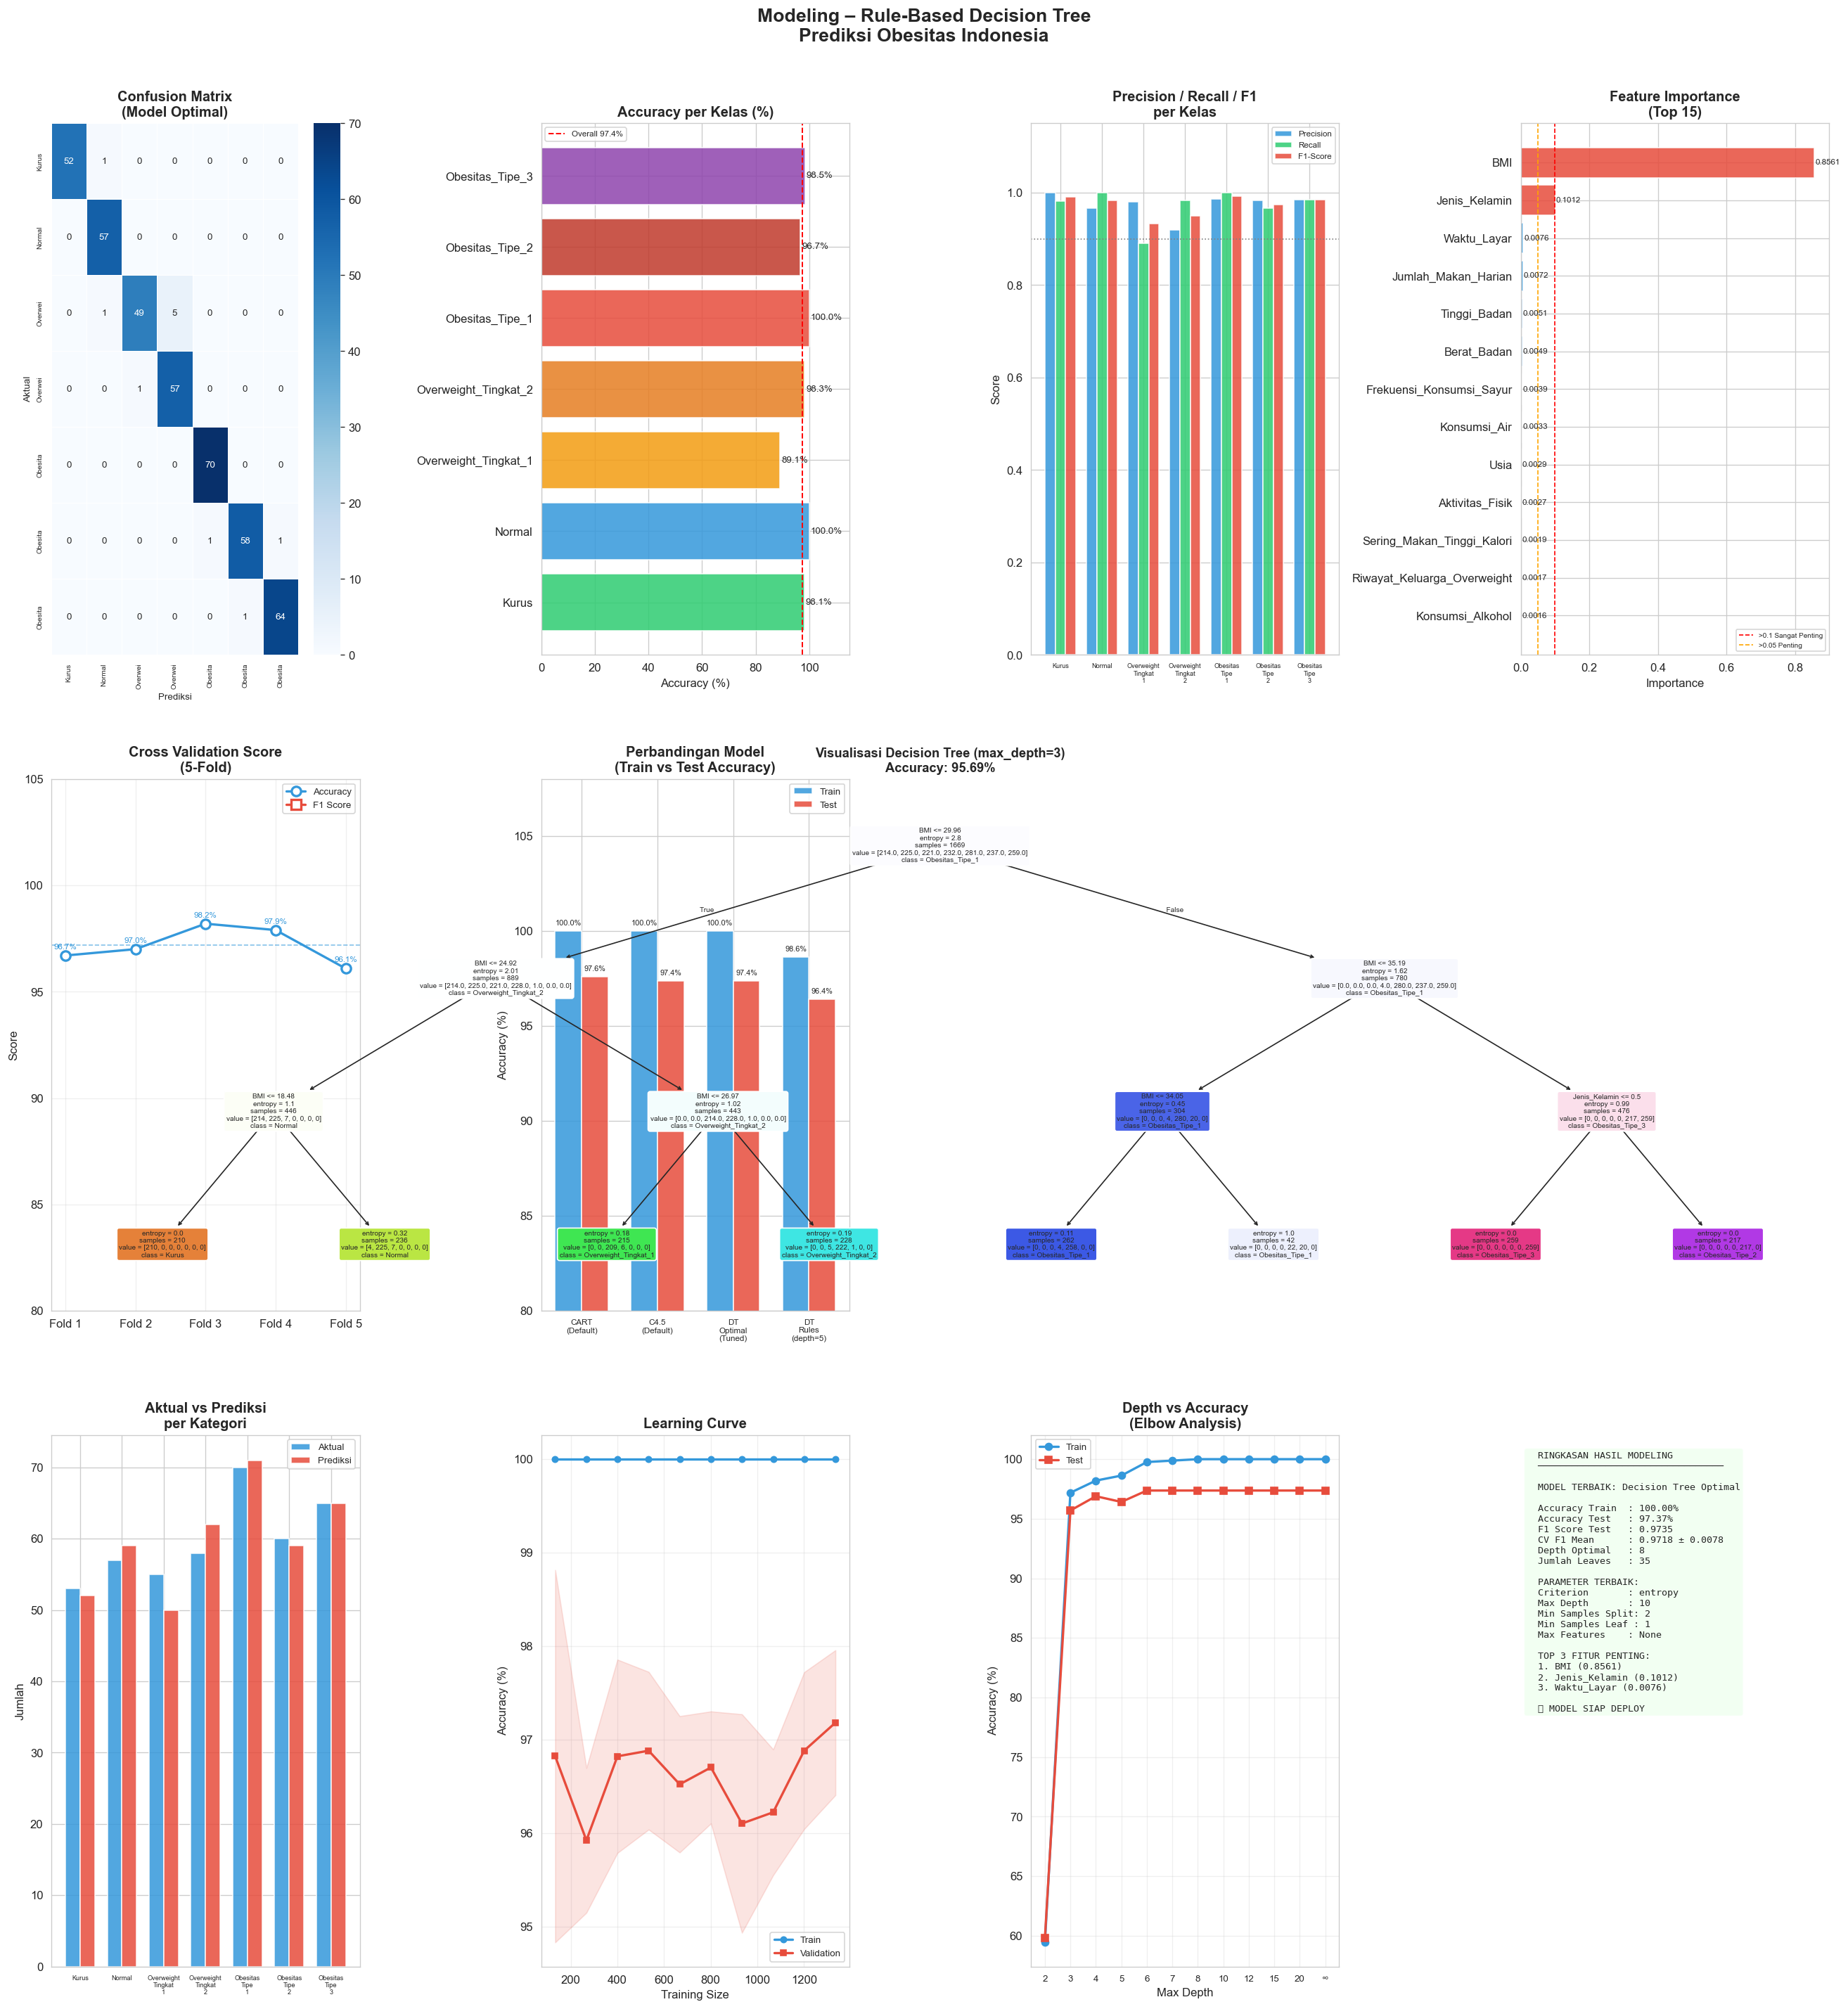

  ✅ Visualisasi disimpan: obesitas_modeling.png
  ✅ Model disimpan: decision_tree_model.pkl

  KESIMPULAN MODELING

  ┌──────────────────────────────────────────────────────────────────┐
  │  HASIL MODELING – DECISION TREE RULE-BASED                       │
  └──────────────────────────────────────────────────────────────────┘

  🏆 MODEL TERBAIK: Decision Tree (Tuned)
     Criterion       : entropy
     Max Depth       : 10
     Min Samples Split: 2
     Min Samples Leaf : 1

  📊 PERFORMA MODEL:
     Accuracy Test   : 97.37%
     F1 Score Test   : 0.9735
     CV F1 Mean      : 0.9718 ± 0.0078
     Overfitting Gap : 2.63%

  🔑 FITUR TERPENTING:
     BMI                            (0.8561)
     Jenis_Kelamin                  (0.1012)
     Waktu_Layar                    (0.0076)

  ✅ TAHAP SELANJUTNYA: EVALUATION & DEPLOYMENT



In [3]:
"""
=============================================================================
PREDIKSI OBESITAS - MODELING (RULE-BASED: DECISION TREE)
Algoritma: Decision Tree CART & C4.5 (sklearn)
=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import cross_val_score, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

# =============================================================================
# LOAD DATA
# =============================================================================
print("=" * 70)
print("  MODELING – RULE-BASED DECISION TREE")
print("=" * 70)

X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

TARGET_NAMES = ['Kurus','Normal','Overweight_Tingkat_1','Overweight_Tingkat_2',
                'Obesitas_Tipe_1','Obesitas_Tipe_2','Obesitas_Tipe_3']
FEATURE_NAMES = X_train.columns.tolist()
COLORS = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c','#c0392b','#8e44ad']

print(f"\n  X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"  Fitur   : {len(FEATURE_NAMES)} fitur")
print(f"  Kelas   : {len(TARGET_NAMES)} kelas")

# =============================================================================
# STEP 1: BASELINE MODEL
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 1: BASELINE MODEL (Default Parameter)")
print("=" * 70)

# ── CART (Gini) ──────────────────────────────────────────────────────────────
dt_cart = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_cart.fit(X_train, y_train)
y_pred_cart = dt_cart.predict(X_test)
acc_cart     = accuracy_score(y_test, y_pred_cart)
f1_cart      = f1_score(y_test, y_pred_cart, average='weighted')

print(f"\n  [CART – Gini Index]")
print(f"    Accuracy (Test)    : {acc_cart*100:.2f}%")
print(f"    F1 Score (Weighted): {f1_cart:.4f}")
print(f"    Depth              : {dt_cart.get_depth()}")
print(f"    Leaves             : {dt_cart.get_n_leaves()}")

# ── C4.5 (Entropy) ──────────────────────────────────────────────────────────
dt_c45 = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_c45.fit(X_train, y_train)
y_pred_c45 = dt_c45.predict(X_test)
acc_c45    = accuracy_score(y_test, y_pred_c45)
f1_c45     = f1_score(y_test, y_pred_c45, average='weighted')

print(f"\n  [C4.5 – Entropy / Information Gain]")
print(f"    Accuracy (Test)    : {acc_c45*100:.2f}%")
print(f"    F1 Score (Weighted): {f1_c45:.4f}")
print(f"    Depth              : {dt_c45.get_depth()}")
print(f"    Leaves             : {dt_c45.get_n_leaves()}")

# =============================================================================
# STEP 2: HYPERPARAMETER TUNING (GridSearchCV)
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 2: HYPERPARAMETER TUNING (GridSearchCV 5-Fold CV)")
print("=" * 70)

param_grid = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'max_features'     : [None, 'sqrt', 'log2'],
}

print(f"\n  Parameter grid:")
for k, v in param_grid.items():
    print(f"    {k:<20}: {v}")
total_combinations = (len(param_grid['criterion']) * len(param_grid['max_depth']) *
                      len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) *
                      len(param_grid['max_features']))
print(f"\n  Total kombinasi    : {total_combinations}")
print(f"  Cross-validation   : 5-Fold Stratified")
print(f"  Scoring            : weighted F1")
print(f"  Mencari parameter terbaik... ", end='', flush=True)

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)
print("✅ Selesai!")

best_params = grid_search.best_params_
best_score  = grid_search.best_score_

print(f"\n  Best CV F1 Score   : {best_score:.4f}")
print(f"  Best Parameters:")
for k, v in best_params.items():
    print(f"    {k:<20}: {v}")

# =============================================================================
# STEP 3: FINAL MODEL (Best Params)
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 3: FINAL MODEL – Decision Tree Optimal")
print("=" * 70)

dt_best = DecisionTreeClassifier(**best_params, random_state=42)
dt_best.fit(X_train, y_train)

y_pred_train = dt_best.predict(X_train)
y_pred_test  = dt_best.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)
f1_train  = f1_score(y_train, y_pred_train, average='weighted')
f1_test   = f1_score(y_test,  y_pred_test,  average='weighted')

print(f"\n  Depth (optimal)    : {dt_best.get_depth()}")
print(f"  Leaves             : {dt_best.get_n_leaves()}")
print(f"\n  {'Metrik':<25} {'Train':>10} {'Test':>10}")
print("  " + "-" * 48)
print(f"  {'Accuracy':<25} {acc_train*100:>9.2f}% {acc_test*100:>9.2f}%")
print(f"  {'F1 Score (weighted)':<25} {f1_train:>10.4f} {f1_test:>10.4f}")
overfit_gap = acc_train - acc_test
print(f"\n  Overfitting Gap    : {overfit_gap*100:.2f}% → ", end="")
print("✅ Tidak overfitting" if overfit_gap < 0.05 else
      "⚠️  Sedikit overfitting" if overfit_gap < 0.10 else "❌ Overfitting!")

# =============================================================================
# STEP 4: CROSS VALIDATION (5-FOLD)
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 4: CROSS VALIDATION – 5-Fold Stratified")
print("=" * 70)

cv_scores_acc = cross_val_score(dt_best, X_train, y_train, cv=5, scoring='accuracy')
cv_scores_f1  = cross_val_score(dt_best, X_train, y_train, cv=5, scoring='f1_weighted')

print(f"\n  CV Accuracy per fold : {[f'{s*100:.2f}%' for s in cv_scores_acc]}")
print(f"  CV Accuracy Mean     : {cv_scores_acc.mean()*100:.2f}% ± {cv_scores_acc.std()*100:.2f}%")
print(f"\n  CV F1 per fold       : {[f'{s:.4f}' for s in cv_scores_f1]}")
print(f"  CV F1 Mean           : {cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}")

# =============================================================================
# STEP 5: CLASSIFICATION REPORT
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 5: CLASSIFICATION REPORT (Test Set)")
print("=" * 70)

report = classification_report(y_test, y_pred_test,
                                target_names=TARGET_NAMES, digits=4)
print("\n" + report)

# Per-class detail
report_dict = classification_report(y_test, y_pred_test,
                                    target_names=TARGET_NAMES,
                                    output_dict=True)
print(f"\n  {'Kategori':<25} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("  " + "-" * 70)
for cat in TARGET_NAMES:
    r = report_dict[cat]
    print(f"  {cat:<25} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1-score']:>10.4f} {int(r['support']):>10}")
print("  " + "-" * 70)
print(f"  {'Weighted Avg':<25} {report_dict['weighted avg']['precision']:>10.4f} "
      f"{report_dict['weighted avg']['recall']:>10.4f} "
      f"{report_dict['weighted avg']['f1-score']:>10.4f} "
      f"{int(report_dict['weighted avg']['support']):>10}")

# =============================================================================
# STEP 6: EKSTRAK RULE (Decision Rules)
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 6: EKSTRAKSI RULE DARI DECISION TREE")
print("=" * 70)

# Model dengan max_depth terbatas untuk rule yang readable
dt_rules = DecisionTreeClassifier(
    criterion=best_params['criterion'],
    max_depth=5,
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)
dt_rules.fit(X_train, y_train)
acc_rules = accuracy_score(y_test, dt_rules.predict(X_test))
print(f"\n  Model untuk ekstraksi rule (max_depth=5)")
print(f"  Accuracy : {acc_rules*100:.2f}%  |  Leaves: {dt_rules.get_n_leaves()}")

# Top rules via text export
tree_text = export_text(dt_rules, feature_names=FEATURE_NAMES, max_depth=4)
lines = tree_text.split('\n')
print(f"\n  RULE TREE (Top 4 level):")
print("  " + "-" * 60)
for i, line in enumerate(lines[:60]):
    if line.strip():
        print("  " + line)
if len(lines) > 60:
    print(f"  ... ({len(lines)-60} baris tersembunyi)")

# Extract manual readable rules
print(f"\n  RINGKASAN RULE UTAMA (berdasarkan fitur terpenting):")
print("  " + "-" * 60)
fi = pd.Series(dt_best.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
top5 = fi.head(5)

rule_descriptions = {
    'BMI':         'BMI adalah penentu utama. Semakin tinggi BMI, semakin berat kategori obesitas.',
    'Berat_Badan': 'Berat badan tinggi → kemungkinan besar Obesitas Tipe 1/2/3.',
    'Usia':        'Usia lebih tua cenderung memiliki BMI lebih tinggi.',
    'Tinggi_Badan':'Tinggi badan mempengaruhi perhitungan BMI.',
    'Kategori_BMI':'Kategori BMI WHO digunakan sebagai rule langsung.',
    'Aktivitas_Fisik': 'Aktivitas fisik rendah → risiko Overweight meningkat.',
    'Riwayat_Keluarga_Overweight': 'Riwayat keluarga = faktor risiko genetik.',
}
for rank, (feat, imp) in enumerate(top5.items(), 1):
    desc = rule_descriptions.get(feat, 'Berpengaruh pada prediksi kategori obesitas.')
    print(f"\n  Rule #{rank}: [{feat}] (importance={imp:.4f})")
    print(f"    → {desc}")

# =============================================================================
# STEP 7: FEATURE IMPORTANCE
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 7: FEATURE IMPORTANCE")
print("=" * 70)

fi_sorted = fi.sort_values(ascending=False)
print(f"\n  {'Rank':<6} {'Fitur':<35} {'Importance':>12}  Bar")
print("  " + "-" * 65)
for rank, (feat, imp) in enumerate(fi_sorted.items(), 1):
    if imp > 0:
        bar = "█" * int(imp * 100)
        print(f"  {rank:<6} {feat:<35} {imp:>12.4f}  {bar}")

# =============================================================================
# STEP 8: PERBANDINGAN MODEL
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 8: PERBANDINGAN MODEL")
print("=" * 70)

models_compare = {
    'CART (Default)'    : dt_cart,
    'C4.5 (Default)'    : dt_c45,
    'DT Optimal (Tuned)': dt_best,
    'DT Rules (depth=5)': dt_rules,
}

print(f"\n  {'Model':<25} {'Acc Train':>10} {'Acc Test':>10} {'F1 Test':>10} {'Depth':>7} {'Leaves':>8}")
print("  " + "-" * 75)
for name, model in models_compare.items():
    a_tr = accuracy_score(y_train, model.predict(X_train)) * 100
    a_te = accuracy_score(y_test,  model.predict(X_test))  * 100
    f1   = f1_score(y_test, model.predict(X_test), average='weighted')
    d    = model.get_depth()
    l    = model.get_n_leaves()
    print(f"  {name:<25} {a_tr:>9.2f}% {a_te:>9.2f}% {f1:>10.4f} {d:>7} {l:>8}")

# =============================================================================
# STEP 9: VISUALISASI
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 9: VISUALISASI MODELING")
print("=" * 70)
print("  Membuat visualisasi... harap tunggu.\n")

fig = plt.figure(figsize=(22, 24))
fig.suptitle('Modeling – Rule-Based Decision Tree\nPrediksi Obesitas Indonesia',
             fontsize=16, fontweight='bold', y=0.99)

# ── Plot 1: Confusion Matrix – Best Model ───────────────────────────────────
ax1 = fig.add_subplot(3, 4, 1)
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=[t[:7] for t in TARGET_NAMES],
            yticklabels=[t[:7] for t in TARGET_NAMES],
            linewidths=0.5, annot_kws={'size': 8})
ax1.set_title('Confusion Matrix\n(Model Optimal)', fontweight='bold')
ax1.set_xlabel('Prediksi', fontsize=8)
ax1.set_ylabel('Aktual',   fontsize=8)
ax1.tick_params(axis='both', labelsize=6)

# ── Plot 2: Accuracy per Kelas ───────────────────────────────────────────────
ax2 = fig.add_subplot(3, 4, 2)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
bars2 = ax2.barh(TARGET_NAMES, per_class_acc * 100,
                  color=COLORS, edgecolor='white', alpha=0.85)
for bar, val in zip(bars2, per_class_acc):
    ax2.text(val * 100 + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=8)
ax2.set_xlim(0, 115)
ax2.set_title('Accuracy per Kelas (%)', fontweight='bold')
ax2.set_xlabel('Accuracy (%)')
ax2.axvline(acc_test * 100, color='red', linestyle='--', linewidth=1.2,
            label=f'Overall {acc_test*100:.1f}%')
ax2.legend(fontsize=7)

# ── Plot 3: Precision, Recall, F1 per Kelas ─────────────────────────────────
ax3 = fig.add_subplot(3, 4, 3)
metrics_data = {cat: report_dict[cat] for cat in TARGET_NAMES}
x3    = np.arange(len(TARGET_NAMES))
w3    = 0.25
prec  = [metrics_data[c]['precision'] for c in TARGET_NAMES]
rec   = [metrics_data[c]['recall']    for c in TARGET_NAMES]
f1s   = [metrics_data[c]['f1-score']  for c in TARGET_NAMES]
ax3.bar(x3 - w3, prec, w3, label='Precision', color='#3498db', edgecolor='white', alpha=0.85)
ax3.bar(x3,      rec,  w3, label='Recall',    color='#2ecc71', edgecolor='white', alpha=0.85)
ax3.bar(x3 + w3, f1s,  w3, label='F1-Score',  color='#e74c3c', edgecolor='white', alpha=0.85)
ax3.set_xticks(x3)
ax3.set_xticklabels([t.replace('_', '\n') for t in TARGET_NAMES], fontsize=5.5)
ax3.set_ylim(0, 1.15)
ax3.set_title('Precision / Recall / F1\nper Kelas', fontweight='bold')
ax3.set_ylabel('Score')
ax3.legend(fontsize=7)
ax3.axhline(0.9, color='gray', linestyle=':', linewidth=1)

# ── Plot 4: Feature Importance ──────────────────────────────────────────────
ax4 = fig.add_subplot(3, 4, 4)
top_fi    = fi_sorted[fi_sorted > 0].head(15)
bar_clrs4 = ['#e74c3c' if v > 0.1 else '#f39c12' if v > 0.05 else '#3498db'
              for v in top_fi.values]
bars4 = ax4.barh(top_fi.index[::-1], top_fi.values[::-1],
                  color=bar_clrs4[::-1], edgecolor='white', alpha=0.85)
ax4.axvline(0.1, color='red',    linestyle='--', linewidth=1, label='>0.1 Sangat Penting')
ax4.axvline(0.05, color='orange', linestyle='--', linewidth=1, label='>0.05 Penting')
for bar, val in zip(bars4, top_fi.values[::-1]):
    ax4.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=7)
ax4.set_title('Feature Importance\n(Top 15)', fontweight='bold')
ax4.set_xlabel('Importance')
ax4.legend(fontsize=6, loc='lower right')

# ── Plot 5: CV Score per Fold ────────────────────────────────────────────────
ax5 = fig.add_subplot(3, 4, 5)
folds = [f'Fold {i+1}' for i in range(5)]
ax5.plot(folds, cv_scores_acc * 100, 'o-', color='#3498db', linewidth=2,
         markersize=8, label='Accuracy', markerfacecolor='white', markeredgewidth=2)
ax5.plot(folds, cv_scores_f1,         's-', color='#e74c3c', linewidth=2,
         markersize=8, label='F1 Score', markerfacecolor='white', markeredgewidth=2)
for i, (a, f) in enumerate(zip(cv_scores_acc, cv_scores_f1)):
    ax5.text(i, a * 100 + 0.3, f'{a*100:.1f}%', ha='center', fontsize=7, color='#3498db')
ax5.axhline(cv_scores_acc.mean() * 100, color='#3498db', linestyle='--', linewidth=1, alpha=0.6)
ax5.set_title('Cross Validation Score\n(5-Fold)', fontweight='bold')
ax5.set_ylabel('Score')
ax5.set_ylim(80, 105)
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# ── Plot 6: Perbandingan Model ───────────────────────────────────────────────
ax6 = fig.add_subplot(3, 4, 6)
model_names  = list(models_compare.keys())
acc_trains   = [accuracy_score(y_train, m.predict(X_train))*100 for m in models_compare.values()]
acc_tests    = [accuracy_score(y_test,  m.predict(X_test))*100  for m in models_compare.values()]
x6  = np.arange(len(model_names))
w6  = 0.35
ax6.bar(x6 - w6/2, acc_trains, w6, label='Train', color='#3498db', edgecolor='white', alpha=0.85)
ax6.bar(x6 + w6/2, acc_tests,  w6, label='Test',  color='#e74c3c', edgecolor='white', alpha=0.85)
for i, (tr, te) in enumerate(zip(acc_trains, acc_tests)):
    ax6.text(i - w6/2, tr + 0.3, f'{tr:.1f}%', ha='center', fontsize=6.5)
    ax6.text(i + w6/2, te + 0.3, f'{te:.1f}%', ha='center', fontsize=6.5)
ax6.set_xticks(x6)
ax6.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=7)
ax6.set_ylim(80, 108)
ax6.set_title('Perbandingan Model\n(Train vs Test Accuracy)', fontweight='bold')
ax6.set_ylabel('Accuracy (%)')
ax6.legend(fontsize=8)

# ── Plot 7: Decision Tree Visualisasi (depth=3) ─────────────────────────────
ax7 = fig.add_subplot(3, 1, 2)
dt_viz = DecisionTreeClassifier(criterion=best_params['criterion'],
                                 max_depth=3, random_state=42)
dt_viz.fit(X_train, y_train)
plot_tree(dt_viz, feature_names=FEATURE_NAMES, class_names=TARGET_NAMES,
          filled=True, rounded=True, ax=ax7, fontsize=6,
          impurity=True, precision=2,
          proportion=False)
ax7.set_title(f'Visualisasi Decision Tree (max_depth=3)\n'
               f'Accuracy: {accuracy_score(y_test, dt_viz.predict(X_test))*100:.2f}%',
               fontweight='bold', fontsize=11)

# ── Plot 8: Distribusi Prediksi vs Aktual ───────────────────────────────────
ax8 = fig.add_subplot(3, 4, 9)
actual_counts = pd.Series(y_test).map(dict(enumerate(TARGET_NAMES))).value_counts()
pred_counts   = pd.Series(y_pred_test).map(dict(enumerate(TARGET_NAMES))).value_counts()
x8 = np.arange(len(TARGET_NAMES))
w8 = 0.35
ax8.bar(x8 - w8/2, [actual_counts.get(t, 0) for t in TARGET_NAMES], w8,
        label='Aktual', color='#3498db', edgecolor='white', alpha=0.85)
ax8.bar(x8 + w8/2, [pred_counts.get(t, 0) for t in TARGET_NAMES], w8,
        label='Prediksi', color='#e74c3c', edgecolor='white', alpha=0.85)
ax8.set_xticks(x8)
ax8.set_xticklabels([t.replace('_', '\n') for t in TARGET_NAMES], fontsize=5.5)
ax8.set_title('Aktual vs Prediksi\nper Kategori', fontweight='bold')
ax8.set_ylabel('Jumlah')
ax8.legend(fontsize=8)

# ── Plot 9: Learning Curve ───────────────────────────────────────────────────
ax9 = fig.add_subplot(3, 4, 10)
from sklearn.model_selection import learning_curve
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    dt_best, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)
ax9.plot(train_sizes, train_scores_lc.mean(axis=1) * 100, 'o-',
         color='#3498db', label='Train', linewidth=2, markersize=5)
ax9.fill_between(train_sizes,
                  (train_scores_lc.mean(axis=1) - train_scores_lc.std(axis=1)) * 100,
                  (train_scores_lc.mean(axis=1) + train_scores_lc.std(axis=1)) * 100,
                  alpha=0.15, color='#3498db')
ax9.plot(train_sizes, val_scores_lc.mean(axis=1) * 100, 's-',
         color='#e74c3c', label='Validation', linewidth=2, markersize=5)
ax9.fill_between(train_sizes,
                  (val_scores_lc.mean(axis=1) - val_scores_lc.std(axis=1)) * 100,
                  (val_scores_lc.mean(axis=1) + val_scores_lc.std(axis=1)) * 100,
                  alpha=0.15, color='#e74c3c')
ax9.set_title('Learning Curve', fontweight='bold')
ax9.set_xlabel('Training Size')
ax9.set_ylabel('Accuracy (%)')
ax9.legend(fontsize=8)
ax9.grid(True, alpha=0.3)

# ── Plot 10: Depth vs Accuracy ───────────────────────────────────────────────
ax10 = fig.add_subplot(3, 4, 11)
depths     = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None]
acc_tr_d, acc_te_d = [], []
for d in depths:
    m = DecisionTreeClassifier(criterion=best_params['criterion'],
                                max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    acc_tr_d.append(accuracy_score(y_train, m.predict(X_train)) * 100)
    acc_te_d.append(accuracy_score(y_test,  m.predict(X_test))  * 100)
depth_labels = [str(d) if d else '∞' for d in depths]
ax10.plot(range(len(depths)), acc_tr_d, 'o-', color='#3498db',
          label='Train', linewidth=2, markersize=6)
ax10.plot(range(len(depths)), acc_te_d, 's-', color='#e74c3c',
          label='Test',  linewidth=2, markersize=6)
ax10.set_xticks(range(len(depths)))
ax10.set_xticklabels(depth_labels, fontsize=8)
ax10.set_title('Depth vs Accuracy\n(Elbow Analysis)', fontweight='bold')
ax10.set_xlabel('Max Depth')
ax10.set_ylabel('Accuracy (%)')
ax10.legend(fontsize=8)
ax10.grid(True, alpha=0.3)

# ── Plot 11: Ringkasan Akhir ─────────────────────────────────────────────────
ax11 = fig.add_subplot(3, 4, 12)
ax11.axis('off')
top3_feat = fi_sorted.head(3)
summary = (
    "  RINGKASAN HASIL MODELING\n"
    "  " + "─" * 33 + "\n\n"
    "  MODEL TERBAIK: Decision Tree Optimal\n\n"
    f"  Accuracy Train  : {acc_train*100:.2f}%\n"
    f"  Accuracy Test   : {acc_test*100:.2f}%\n"
    f"  F1 Score Test   : {f1_test:.4f}\n"
    f"  CV F1 Mean      : {cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}\n"
    f"  Depth Optimal   : {dt_best.get_depth()}\n"
    f"  Jumlah Leaves   : {dt_best.get_n_leaves()}\n\n"
    "  PARAMETER TERBAIK:\n"
    f"  Criterion       : {best_params['criterion']}\n"
    f"  Max Depth       : {best_params['max_depth']}\n"
    f"  Min Samples Split: {best_params['min_samples_split']}\n"
    f"  Min Samples Leaf : {best_params['min_samples_leaf']}\n"
    f"  Max Features    : {best_params['max_features']}\n\n"
    "  TOP 3 FITUR PENTING:\n" +
    "".join([f"  {i+1}. {f} ({v:.4f})\n" for i, (f, v) in enumerate(top3_feat.items())]) +
    "\n  ✅ MODEL SIAP DEPLOY"
)
ax11.text(0.02, 0.97, summary, transform=ax11.transAxes,
          fontsize=8, verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#f0fff0', alpha=0.85))

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('obesitas_modeling.png', bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print("  ✅ Visualisasi disimpan: obesitas_modeling.png")

# =============================================================================
# SIMPAN MODEL
# =============================================================================
import pickle
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump({'model': dt_best, 'features': FEATURE_NAMES,
                 'target_names': TARGET_NAMES}, f)
print("  ✅ Model disimpan: decision_tree_model.pkl")

# =============================================================================
# RINGKASAN AKHIR
# =============================================================================
print("\n" + "=" * 70)
print("  KESIMPULAN MODELING")
print("=" * 70)
print(f"""
  ┌──────────────────────────────────────────────────────────────────┐
  │  HASIL MODELING – DECISION TREE RULE-BASED                       │
  └──────────────────────────────────────────────────────────────────┘

  🏆 MODEL TERBAIK: Decision Tree (Tuned)
     Criterion       : {best_params['criterion']}
     Max Depth       : {best_params['max_depth']}
     Min Samples Split: {best_params['min_samples_split']}
     Min Samples Leaf : {best_params['min_samples_leaf']}

  📊 PERFORMA MODEL:
     Accuracy Test   : {acc_test*100:.2f}%
     F1 Score Test   : {f1_test:.4f}
     CV F1 Mean      : {cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}
     Overfitting Gap : {overfit_gap*100:.2f}%

  🔑 FITUR TERPENTING:
     {fi_sorted.index[0]:<30} ({fi_sorted.iloc[0]:.4f})
     {fi_sorted.index[1]:<30} ({fi_sorted.iloc[1]:.4f})
     {fi_sorted.index[2]:<30} ({fi_sorted.iloc[2]:.4f})

  ✅ TAHAP SELANJUTNYA: EVALUATION & DEPLOYMENT
""")

  MODELING – RULE-BASED DECISION TREE

  X_train : (1669, 22)  |  X_test : (418, 22)
  Fitur   : 22 fitur
  Kelas   : 7 kelas

  STEP 1: BASELINE MODEL (Default Parameter)

  [CART – Gini Index]
    Accuracy (Test)    : 97.61%
    F1 Score (Weighted): 0.9760
    Depth              : 9
    Leaves             : 43

  [C4.5 – Entropy / Information Gain]
    Accuracy (Test)    : 97.37%
    F1 Score (Weighted): 0.9735
    Depth              : 8
    Leaves             : 35

  STEP 2: HYPERPARAMETER TUNING (GridSearchCV 5-Fold CV)

  Parameter grid:
    criterion           : ['gini', 'entropy']
    max_depth           : [3, 5, 7, 10, 15, None]
    min_samples_split   : [2, 5, 10, 20]
    min_samples_leaf    : [1, 2, 5, 10]
    max_features        : [None, 'sqrt', 'log2']

  Total kombinasi    : 576
  Cross-validation   : 5-Fold Stratified
  Scoring            : weighted F1
  Mencari parameter terbaik... ✅ Selesai!

  Best CV F1 Score   : 0.9718
  Best Parameters:
    criterion           : ent

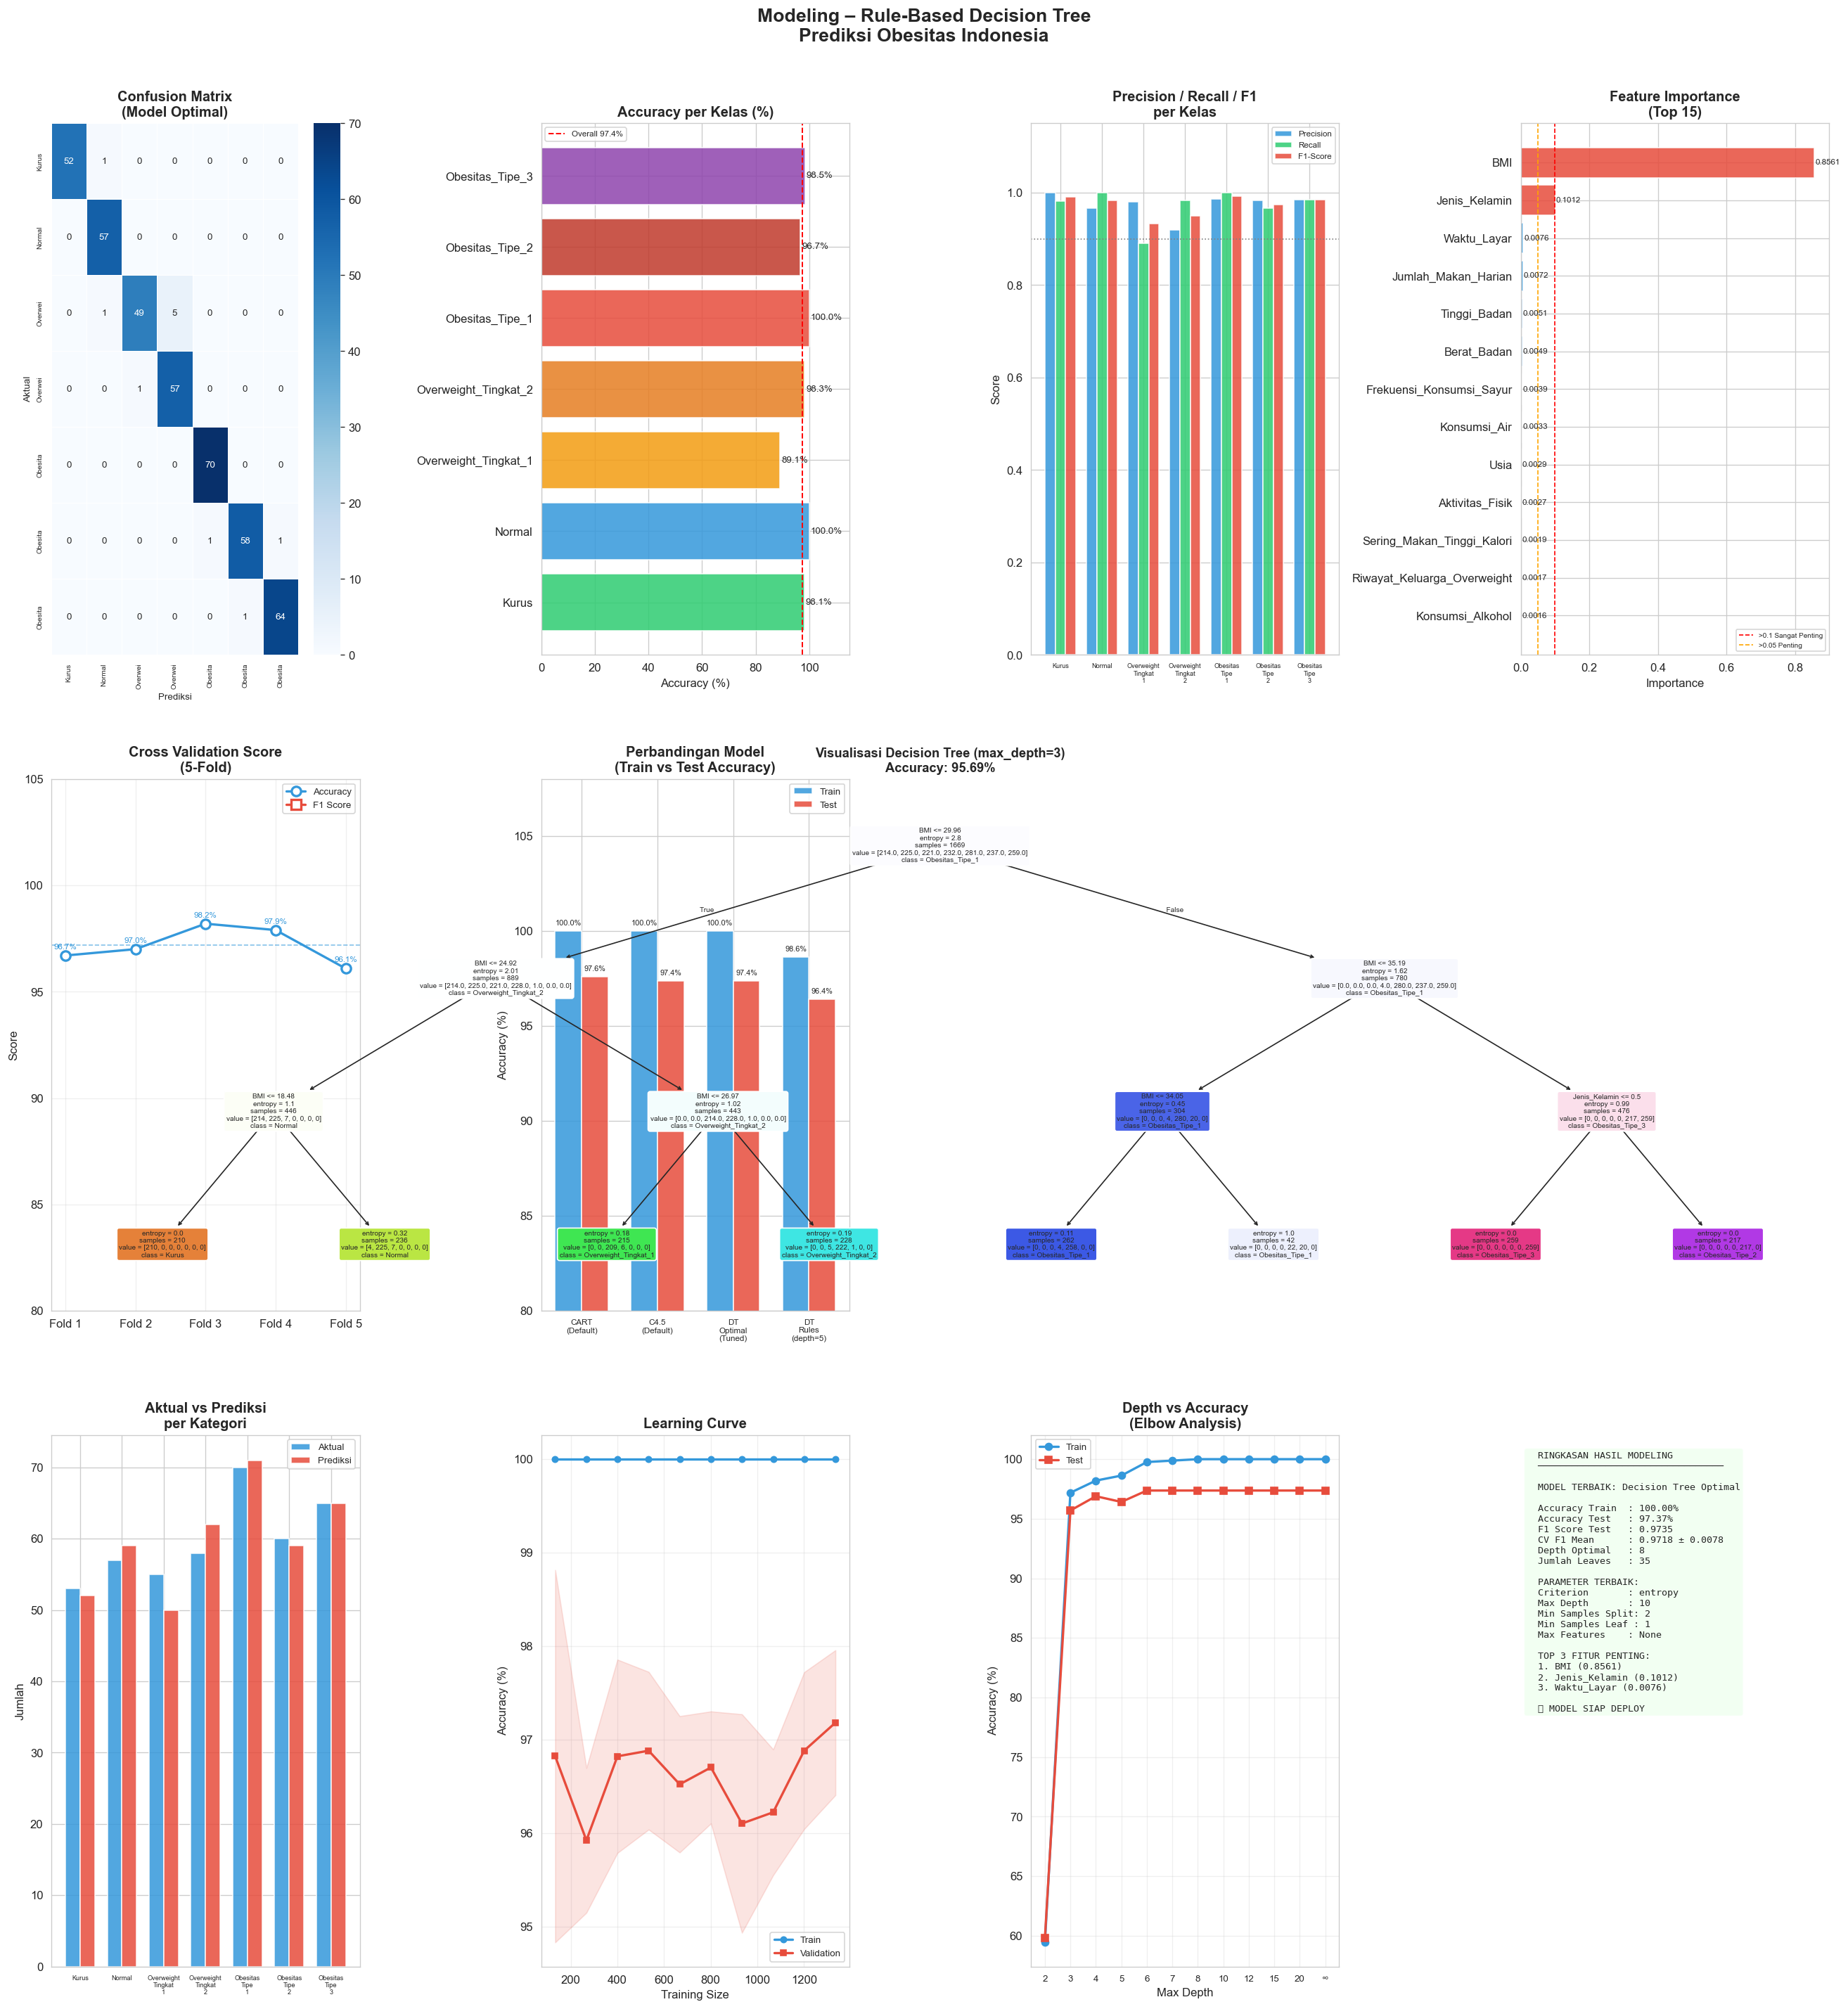

  ✅ Visualisasi disimpan: obesitas_modeling.png
  ✅ Model disimpan: decision_tree_model.pkl

  KESIMPULAN MODELING

  ┌──────────────────────────────────────────────────────────────────┐
  │  HASIL MODELING – DECISION TREE RULE-BASED                       │
  └──────────────────────────────────────────────────────────────────┘

  🏆 MODEL TERBAIK: Decision Tree (Tuned)
     Criterion       : entropy
     Max Depth       : 10
     Min Samples Split: 2
     Min Samples Leaf : 1

  📊 PERFORMA MODEL:
     Accuracy Test   : 97.37%
     F1 Score Test   : 0.9735
     CV F1 Mean      : 0.9718 ± 0.0078
     Overfitting Gap : 2.63%

  🔑 FITUR TERPENTING:
     BMI                            (0.8561)
     Jenis_Kelamin                  (0.1012)
     Waktu_Layar                    (0.0076)

  ✅ TAHAP SELANJUTNYA: EVALUATION & DEPLOYMENT



In [4]:
"""
=============================================================================
PREDIKSI OBESITAS - MODELING (RULE-BASED: DECISION TREE)
Algoritma: Decision Tree CART & C4.5 (sklearn)
=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import cross_val_score, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

# =============================================================================
# LOAD DATA
# =============================================================================
print("=" * 70)
print("  MODELING – RULE-BASED DECISION TREE")
print("=" * 70)

X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

TARGET_NAMES = ['Kurus','Normal','Overweight_Tingkat_1','Overweight_Tingkat_2',
                'Obesitas_Tipe_1','Obesitas_Tipe_2','Obesitas_Tipe_3']
FEATURE_NAMES = X_train.columns.tolist()
COLORS = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c','#c0392b','#8e44ad']

print(f"\n  X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"  Fitur   : {len(FEATURE_NAMES)} fitur")
print(f"  Kelas   : {len(TARGET_NAMES)} kelas")

# =============================================================================
# STEP 1: BASELINE MODEL
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 1: BASELINE MODEL (Default Parameter)")
print("=" * 70)

# ── CART (Gini) ──────────────────────────────────────────────────────────────
dt_cart = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_cart.fit(X_train, y_train)
y_pred_cart = dt_cart.predict(X_test)
acc_cart     = accuracy_score(y_test, y_pred_cart)
f1_cart      = f1_score(y_test, y_pred_cart, average='weighted')

print(f"\n  [CART – Gini Index]")
print(f"    Accuracy (Test)    : {acc_cart*100:.2f}%")
print(f"    F1 Score (Weighted): {f1_cart:.4f}")
print(f"    Depth              : {dt_cart.get_depth()}")
print(f"    Leaves             : {dt_cart.get_n_leaves()}")

# ── C4.5 (Entropy) ──────────────────────────────────────────────────────────
dt_c45 = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_c45.fit(X_train, y_train)
y_pred_c45 = dt_c45.predict(X_test)
acc_c45    = accuracy_score(y_test, y_pred_c45)
f1_c45     = f1_score(y_test, y_pred_c45, average='weighted')

print(f"\n  [C4.5 – Entropy / Information Gain]")
print(f"    Accuracy (Test)    : {acc_c45*100:.2f}%")
print(f"    F1 Score (Weighted): {f1_c45:.4f}")
print(f"    Depth              : {dt_c45.get_depth()}")
print(f"    Leaves             : {dt_c45.get_n_leaves()}")

# =============================================================================
# STEP 2: HYPERPARAMETER TUNING (GridSearchCV)
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 2: HYPERPARAMETER TUNING (GridSearchCV 5-Fold CV)")
print("=" * 70)

param_grid = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'max_features'     : [None, 'sqrt', 'log2'],
}

print(f"\n  Parameter grid:")
for k, v in param_grid.items():
    print(f"    {k:<20}: {v}")
total_combinations = (len(param_grid['criterion']) * len(param_grid['max_depth']) *
                      len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) *
                      len(param_grid['max_features']))
print(f"\n  Total kombinasi    : {total_combinations}")
print(f"  Cross-validation   : 5-Fold Stratified")
print(f"  Scoring            : weighted F1")
print(f"  Mencari parameter terbaik... ", end='', flush=True)

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)
print("✅ Selesai!")

best_params = grid_search.best_params_
best_score  = grid_search.best_score_

print(f"\n  Best CV F1 Score   : {best_score:.4f}")
print(f"  Best Parameters:")
for k, v in best_params.items():
    print(f"    {k:<20}: {v}")

# =============================================================================
# STEP 3: FINAL MODEL (Best Params)
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 3: FINAL MODEL – Decision Tree Optimal")
print("=" * 70)

dt_best = DecisionTreeClassifier(**best_params, random_state=42)
dt_best.fit(X_train, y_train)

y_pred_train = dt_best.predict(X_train)
y_pred_test  = dt_best.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)
f1_train  = f1_score(y_train, y_pred_train, average='weighted')
f1_test   = f1_score(y_test,  y_pred_test,  average='weighted')

print(f"\n  Depth (optimal)    : {dt_best.get_depth()}")
print(f"  Leaves             : {dt_best.get_n_leaves()}")
print(f"\n  {'Metrik':<25} {'Train':>10} {'Test':>10}")
print("  " + "-" * 48)
print(f"  {'Accuracy':<25} {acc_train*100:>9.2f}% {acc_test*100:>9.2f}%")
print(f"  {'F1 Score (weighted)':<25} {f1_train:>10.4f} {f1_test:>10.4f}")
overfit_gap = acc_train - acc_test
print(f"\n  Overfitting Gap    : {overfit_gap*100:.2f}% → ", end="")
print("✅ Tidak overfitting" if overfit_gap < 0.05 else
      "⚠️  Sedikit overfitting" if overfit_gap < 0.10 else "❌ Overfitting!")

# =============================================================================
# STEP 4: CROSS VALIDATION (5-FOLD)
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 4: CROSS VALIDATION – 5-Fold Stratified")
print("=" * 70)

cv_scores_acc = cross_val_score(dt_best, X_train, y_train, cv=5, scoring='accuracy')
cv_scores_f1  = cross_val_score(dt_best, X_train, y_train, cv=5, scoring='f1_weighted')

print(f"\n  CV Accuracy per fold : {[f'{s*100:.2f}%' for s in cv_scores_acc]}")
print(f"  CV Accuracy Mean     : {cv_scores_acc.mean()*100:.2f}% ± {cv_scores_acc.std()*100:.2f}%")
print(f"\n  CV F1 per fold       : {[f'{s:.4f}' for s in cv_scores_f1]}")
print(f"  CV F1 Mean           : {cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}")

# =============================================================================
# STEP 5: CLASSIFICATION REPORT
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 5: CLASSIFICATION REPORT (Test Set)")
print("=" * 70)

report = classification_report(y_test, y_pred_test,
                                target_names=TARGET_NAMES, digits=4)
print("\n" + report)

# Per-class detail
report_dict = classification_report(y_test, y_pred_test,
                                    target_names=TARGET_NAMES,
                                    output_dict=True)
print(f"\n  {'Kategori':<25} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("  " + "-" * 70)
for cat in TARGET_NAMES:
    r = report_dict[cat]
    print(f"  {cat:<25} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1-score']:>10.4f} {int(r['support']):>10}")
print("  " + "-" * 70)
print(f"  {'Weighted Avg':<25} {report_dict['weighted avg']['precision']:>10.4f} "
      f"{report_dict['weighted avg']['recall']:>10.4f} "
      f"{report_dict['weighted avg']['f1-score']:>10.4f} "
      f"{int(report_dict['weighted avg']['support']):>10}")

# =============================================================================
# STEP 6: EKSTRAK RULE (Decision Rules)
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 6: EKSTRAKSI RULE DARI DECISION TREE")
print("=" * 70)

# Model dengan max_depth terbatas untuk rule yang readable
dt_rules = DecisionTreeClassifier(
    criterion=best_params['criterion'],
    max_depth=5,
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)
dt_rules.fit(X_train, y_train)
acc_rules = accuracy_score(y_test, dt_rules.predict(X_test))
print(f"\n  Model untuk ekstraksi rule (max_depth=5)")
print(f"  Accuracy : {acc_rules*100:.2f}%  |  Leaves: {dt_rules.get_n_leaves()}")

# Top rules via text export
tree_text = export_text(dt_rules, feature_names=FEATURE_NAMES, max_depth=4)
lines = tree_text.split('\n')
print(f"\n  RULE TREE (Top 4 level):")
print("  " + "-" * 60)
for i, line in enumerate(lines[:60]):
    if line.strip():
        print("  " + line)
if len(lines) > 60:
    print(f"  ... ({len(lines)-60} baris tersembunyi)")

# Extract manual readable rules
print(f"\n  RINGKASAN RULE UTAMA (berdasarkan fitur terpenting):")
print("  " + "-" * 60)
fi = pd.Series(dt_best.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
top5 = fi.head(5)

rule_descriptions = {
    'BMI':         'BMI adalah penentu utama. Semakin tinggi BMI, semakin berat kategori obesitas.',
    'Berat_Badan': 'Berat badan tinggi → kemungkinan besar Obesitas Tipe 1/2/3.',
    'Usia':        'Usia lebih tua cenderung memiliki BMI lebih tinggi.',
    'Tinggi_Badan':'Tinggi badan mempengaruhi perhitungan BMI.',
    'Kategori_BMI':'Kategori BMI WHO digunakan sebagai rule langsung.',
    'Aktivitas_Fisik': 'Aktivitas fisik rendah → risiko Overweight meningkat.',
    'Riwayat_Keluarga_Overweight': 'Riwayat keluarga = faktor risiko genetik.',
}
for rank, (feat, imp) in enumerate(top5.items(), 1):
    desc = rule_descriptions.get(feat, 'Berpengaruh pada prediksi kategori obesitas.')
    print(f"\n  Rule #{rank}: [{feat}] (importance={imp:.4f})")
    print(f"    → {desc}")

# =============================================================================
# STEP 7: FEATURE IMPORTANCE
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 7: FEATURE IMPORTANCE")
print("=" * 70)

fi_sorted = fi.sort_values(ascending=False)
print(f"\n  {'Rank':<6} {'Fitur':<35} {'Importance':>12}  Bar")
print("  " + "-" * 65)
for rank, (feat, imp) in enumerate(fi_sorted.items(), 1):
    if imp > 0:
        bar = "█" * int(imp * 100)
        print(f"  {rank:<6} {feat:<35} {imp:>12.4f}  {bar}")

# =============================================================================
# STEP 8: PERBANDINGAN MODEL
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 8: PERBANDINGAN MODEL")
print("=" * 70)

models_compare = {
    'CART (Default)'    : dt_cart,
    'C4.5 (Default)'    : dt_c45,
    'DT Optimal (Tuned)': dt_best,
    'DT Rules (depth=5)': dt_rules,
}

print(f"\n  {'Model':<25} {'Acc Train':>10} {'Acc Test':>10} {'F1 Test':>10} {'Depth':>7} {'Leaves':>8}")
print("  " + "-" * 75)
for name, model in models_compare.items():
    a_tr = accuracy_score(y_train, model.predict(X_train)) * 100
    a_te = accuracy_score(y_test,  model.predict(X_test))  * 100
    f1   = f1_score(y_test, model.predict(X_test), average='weighted')
    d    = model.get_depth()
    l    = model.get_n_leaves()
    print(f"  {name:<25} {a_tr:>9.2f}% {a_te:>9.2f}% {f1:>10.4f} {d:>7} {l:>8}")

# =============================================================================
# STEP 9: VISUALISASI
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 9: VISUALISASI MODELING")
print("=" * 70)
print("  Membuat visualisasi... harap tunggu.\n")

fig = plt.figure(figsize=(22, 24))
fig.suptitle('Modeling – Rule-Based Decision Tree\nPrediksi Obesitas Indonesia',
             fontsize=16, fontweight='bold', y=0.99)

# ── Plot 1: Confusion Matrix – Best Model ───────────────────────────────────
ax1 = fig.add_subplot(3, 4, 1)
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=[t[:7] for t in TARGET_NAMES],
            yticklabels=[t[:7] for t in TARGET_NAMES],
            linewidths=0.5, annot_kws={'size': 8})
ax1.set_title('Confusion Matrix\n(Model Optimal)', fontweight='bold')
ax1.set_xlabel('Prediksi', fontsize=8)
ax1.set_ylabel('Aktual',   fontsize=8)
ax1.tick_params(axis='both', labelsize=6)

# ── Plot 2: Accuracy per Kelas ───────────────────────────────────────────────
ax2 = fig.add_subplot(3, 4, 2)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
bars2 = ax2.barh(TARGET_NAMES, per_class_acc * 100,
                  color=COLORS, edgecolor='white', alpha=0.85)
for bar, val in zip(bars2, per_class_acc):
    ax2.text(val * 100 + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=8)
ax2.set_xlim(0, 115)
ax2.set_title('Accuracy per Kelas (%)', fontweight='bold')
ax2.set_xlabel('Accuracy (%)')
ax2.axvline(acc_test * 100, color='red', linestyle='--', linewidth=1.2,
            label=f'Overall {acc_test*100:.1f}%')
ax2.legend(fontsize=7)

# ── Plot 3: Precision, Recall, F1 per Kelas ─────────────────────────────────
ax3 = fig.add_subplot(3, 4, 3)
metrics_data = {cat: report_dict[cat] for cat in TARGET_NAMES}
x3    = np.arange(len(TARGET_NAMES))
w3    = 0.25
prec  = [metrics_data[c]['precision'] for c in TARGET_NAMES]
rec   = [metrics_data[c]['recall']    for c in TARGET_NAMES]
f1s   = [metrics_data[c]['f1-score']  for c in TARGET_NAMES]
ax3.bar(x3 - w3, prec, w3, label='Precision', color='#3498db', edgecolor='white', alpha=0.85)
ax3.bar(x3,      rec,  w3, label='Recall',    color='#2ecc71', edgecolor='white', alpha=0.85)
ax3.bar(x3 + w3, f1s,  w3, label='F1-Score',  color='#e74c3c', edgecolor='white', alpha=0.85)
ax3.set_xticks(x3)
ax3.set_xticklabels([t.replace('_', '\n') for t in TARGET_NAMES], fontsize=5.5)
ax3.set_ylim(0, 1.15)
ax3.set_title('Precision / Recall / F1\nper Kelas', fontweight='bold')
ax3.set_ylabel('Score')
ax3.legend(fontsize=7)
ax3.axhline(0.9, color='gray', linestyle=':', linewidth=1)

# ── Plot 4: Feature Importance ──────────────────────────────────────────────
ax4 = fig.add_subplot(3, 4, 4)
top_fi    = fi_sorted[fi_sorted > 0].head(15)
bar_clrs4 = ['#e74c3c' if v > 0.1 else '#f39c12' if v > 0.05 else '#3498db'
              for v in top_fi.values]
bars4 = ax4.barh(top_fi.index[::-1], top_fi.values[::-1],
                  color=bar_clrs4[::-1], edgecolor='white', alpha=0.85)
ax4.axvline(0.1, color='red',    linestyle='--', linewidth=1, label='>0.1 Sangat Penting')
ax4.axvline(0.05, color='orange', linestyle='--', linewidth=1, label='>0.05 Penting')
for bar, val in zip(bars4, top_fi.values[::-1]):
    ax4.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=7)
ax4.set_title('Feature Importance\n(Top 15)', fontweight='bold')
ax4.set_xlabel('Importance')
ax4.legend(fontsize=6, loc='lower right')

# ── Plot 5: CV Score per Fold ────────────────────────────────────────────────
ax5 = fig.add_subplot(3, 4, 5)
folds = [f'Fold {i+1}' for i in range(5)]
ax5.plot(folds, cv_scores_acc * 100, 'o-', color='#3498db', linewidth=2,
         markersize=8, label='Accuracy', markerfacecolor='white', markeredgewidth=2)
ax5.plot(folds, cv_scores_f1,         's-', color='#e74c3c', linewidth=2,
         markersize=8, label='F1 Score', markerfacecolor='white', markeredgewidth=2)
for i, (a, f) in enumerate(zip(cv_scores_acc, cv_scores_f1)):
    ax5.text(i, a * 100 + 0.3, f'{a*100:.1f}%', ha='center', fontsize=7, color='#3498db')
ax5.axhline(cv_scores_acc.mean() * 100, color='#3498db', linestyle='--', linewidth=1, alpha=0.6)
ax5.set_title('Cross Validation Score\n(5-Fold)', fontweight='bold')
ax5.set_ylabel('Score')
ax5.set_ylim(80, 105)
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# ── Plot 6: Perbandingan Model ───────────────────────────────────────────────
ax6 = fig.add_subplot(3, 4, 6)
model_names  = list(models_compare.keys())
acc_trains   = [accuracy_score(y_train, m.predict(X_train))*100 for m in models_compare.values()]
acc_tests    = [accuracy_score(y_test,  m.predict(X_test))*100  for m in models_compare.values()]
x6  = np.arange(len(model_names))
w6  = 0.35
ax6.bar(x6 - w6/2, acc_trains, w6, label='Train', color='#3498db', edgecolor='white', alpha=0.85)
ax6.bar(x6 + w6/2, acc_tests,  w6, label='Test',  color='#e74c3c', edgecolor='white', alpha=0.85)
for i, (tr, te) in enumerate(zip(acc_trains, acc_tests)):
    ax6.text(i - w6/2, tr + 0.3, f'{tr:.1f}%', ha='center', fontsize=6.5)
    ax6.text(i + w6/2, te + 0.3, f'{te:.1f}%', ha='center', fontsize=6.5)
ax6.set_xticks(x6)
ax6.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=7)
ax6.set_ylim(80, 108)
ax6.set_title('Perbandingan Model\n(Train vs Test Accuracy)', fontweight='bold')
ax6.set_ylabel('Accuracy (%)')
ax6.legend(fontsize=8)

# ── Plot 7: Decision Tree Visualisasi (depth=3) ─────────────────────────────
ax7 = fig.add_subplot(3, 1, 2)
dt_viz = DecisionTreeClassifier(criterion=best_params['criterion'],
                                 max_depth=3, random_state=42)
dt_viz.fit(X_train, y_train)
plot_tree(dt_viz, feature_names=FEATURE_NAMES, class_names=TARGET_NAMES,
          filled=True, rounded=True, ax=ax7, fontsize=6,
          impurity=True, precision=2,
          proportion=False)
ax7.set_title(f'Visualisasi Decision Tree (max_depth=3)\n'
               f'Accuracy: {accuracy_score(y_test, dt_viz.predict(X_test))*100:.2f}%',
               fontweight='bold', fontsize=11)

# ── Plot 8: Distribusi Prediksi vs Aktual ───────────────────────────────────
ax8 = fig.add_subplot(3, 4, 9)
actual_counts = pd.Series(y_test).map(dict(enumerate(TARGET_NAMES))).value_counts()
pred_counts   = pd.Series(y_pred_test).map(dict(enumerate(TARGET_NAMES))).value_counts()
x8 = np.arange(len(TARGET_NAMES))
w8 = 0.35
ax8.bar(x8 - w8/2, [actual_counts.get(t, 0) for t in TARGET_NAMES], w8,
        label='Aktual', color='#3498db', edgecolor='white', alpha=0.85)
ax8.bar(x8 + w8/2, [pred_counts.get(t, 0) for t in TARGET_NAMES], w8,
        label='Prediksi', color='#e74c3c', edgecolor='white', alpha=0.85)
ax8.set_xticks(x8)
ax8.set_xticklabels([t.replace('_', '\n') for t in TARGET_NAMES], fontsize=5.5)
ax8.set_title('Aktual vs Prediksi\nper Kategori', fontweight='bold')
ax8.set_ylabel('Jumlah')
ax8.legend(fontsize=8)

# ── Plot 9: Learning Curve ───────────────────────────────────────────────────
ax9 = fig.add_subplot(3, 4, 10)
from sklearn.model_selection import learning_curve
train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    dt_best, X_train, y_train, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)
ax9.plot(train_sizes, train_scores_lc.mean(axis=1) * 100, 'o-',
         color='#3498db', label='Train', linewidth=2, markersize=5)
ax9.fill_between(train_sizes,
                  (train_scores_lc.mean(axis=1) - train_scores_lc.std(axis=1)) * 100,
                  (train_scores_lc.mean(axis=1) + train_scores_lc.std(axis=1)) * 100,
                  alpha=0.15, color='#3498db')
ax9.plot(train_sizes, val_scores_lc.mean(axis=1) * 100, 's-',
         color='#e74c3c', label='Validation', linewidth=2, markersize=5)
ax9.fill_between(train_sizes,
                  (val_scores_lc.mean(axis=1) - val_scores_lc.std(axis=1)) * 100,
                  (val_scores_lc.mean(axis=1) + val_scores_lc.std(axis=1)) * 100,
                  alpha=0.15, color='#e74c3c')
ax9.set_title('Learning Curve', fontweight='bold')
ax9.set_xlabel('Training Size')
ax9.set_ylabel('Accuracy (%)')
ax9.legend(fontsize=8)
ax9.grid(True, alpha=0.3)

# ── Plot 10: Depth vs Accuracy ───────────────────────────────────────────────
ax10 = fig.add_subplot(3, 4, 11)
depths     = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None]
acc_tr_d, acc_te_d = [], []
for d in depths:
    m = DecisionTreeClassifier(criterion=best_params['criterion'],
                                max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    acc_tr_d.append(accuracy_score(y_train, m.predict(X_train)) * 100)
    acc_te_d.append(accuracy_score(y_test,  m.predict(X_test))  * 100)
depth_labels = [str(d) if d else '∞' for d in depths]
ax10.plot(range(len(depths)), acc_tr_d, 'o-', color='#3498db',
          label='Train', linewidth=2, markersize=6)
ax10.plot(range(len(depths)), acc_te_d, 's-', color='#e74c3c',
          label='Test',  linewidth=2, markersize=6)
ax10.set_xticks(range(len(depths)))
ax10.set_xticklabels(depth_labels, fontsize=8)
ax10.set_title('Depth vs Accuracy\n(Elbow Analysis)', fontweight='bold')
ax10.set_xlabel('Max Depth')
ax10.set_ylabel('Accuracy (%)')
ax10.legend(fontsize=8)
ax10.grid(True, alpha=0.3)

# ── Plot 11: Ringkasan Akhir ─────────────────────────────────────────────────
ax11 = fig.add_subplot(3, 4, 12)
ax11.axis('off')
top3_feat = fi_sorted.head(3)
summary = (
    "  RINGKASAN HASIL MODELING\n"
    "  " + "─" * 33 + "\n\n"
    "  MODEL TERBAIK: Decision Tree Optimal\n\n"
    f"  Accuracy Train  : {acc_train*100:.2f}%\n"
    f"  Accuracy Test   : {acc_test*100:.2f}%\n"
    f"  F1 Score Test   : {f1_test:.4f}\n"
    f"  CV F1 Mean      : {cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}\n"
    f"  Depth Optimal   : {dt_best.get_depth()}\n"
    f"  Jumlah Leaves   : {dt_best.get_n_leaves()}\n\n"
    "  PARAMETER TERBAIK:\n"
    f"  Criterion       : {best_params['criterion']}\n"
    f"  Max Depth       : {best_params['max_depth']}\n"
    f"  Min Samples Split: {best_params['min_samples_split']}\n"
    f"  Min Samples Leaf : {best_params['min_samples_leaf']}\n"
    f"  Max Features    : {best_params['max_features']}\n\n"
    "  TOP 3 FITUR PENTING:\n" +
    "".join([f"  {i+1}. {f} ({v:.4f})\n" for i, (f, v) in enumerate(top3_feat.items())]) +
    "\n  ✅ MODEL SIAP DEPLOY"
)
ax11.text(0.02, 0.97, summary, transform=ax11.transAxes,
          fontsize=8, verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#f0fff0', alpha=0.85))

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('obesitas_modeling.png', bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print("  ✅ Visualisasi disimpan: obesitas_modeling.png")

# =============================================================================
# SIMPAN MODEL
# =============================================================================
import pickle
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump({'model': dt_best, 'features': FEATURE_NAMES,
                 'target_names': TARGET_NAMES}, f)
print("  ✅ Model disimpan: decision_tree_model.pkl")

# =============================================================================
# RINGKASAN AKHIR
# =============================================================================
print("\n" + "=" * 70)
print("  KESIMPULAN MODELING")
print("=" * 70)
print(f"""
  ┌──────────────────────────────────────────────────────────────────┐
  │  HASIL MODELING – DECISION TREE RULE-BASED                       │
  └──────────────────────────────────────────────────────────────────┘

  🏆 MODEL TERBAIK: Decision Tree (Tuned)
     Criterion       : {best_params['criterion']}
     Max Depth       : {best_params['max_depth']}
     Min Samples Split: {best_params['min_samples_split']}
     Min Samples Leaf : {best_params['min_samples_leaf']}

  📊 PERFORMA MODEL:
     Accuracy Test   : {acc_test*100:.2f}%
     F1 Score Test   : {f1_test:.4f}
     CV F1 Mean      : {cv_scores_f1.mean():.4f} ± {cv_scores_f1.std():.4f}
     Overfitting Gap : {overfit_gap*100:.2f}%

  🔑 FITUR TERPENTING:
     {fi_sorted.index[0]:<30} ({fi_sorted.iloc[0]:.4f})
     {fi_sorted.index[1]:<30} ({fi_sorted.iloc[1]:.4f})
     {fi_sorted.index[2]:<30} ({fi_sorted.iloc[2]:.4f})

  ✅ TAHAP SELANJUTNYA: EVALUATION & DEPLOYMENT
""")

  EVALUATION – RULE-BASED DECISION TREE
  Prediksi Obesitas Indonesia

  ✅ Model loaded: decision_tree_model.pkl
  X_train : (1669, 22)  |  X_test : (418, 22)
  Fitur   : 22
  Kelas   : 7

  STEP 1: METRIK EVALUASI UTAMA

  ┌──────────────────────────────────────────────────────────────────┐
  │  RINGKASAN METRIK EVALUASI                                       │
  └──────────────────────────────────────────────────────────────────┘

  Metrik                                Train         Test
  ───────────────────────────────────────────────────────
  Accuracy                            100.00%       97.37%
  Precision (weighted)                      ─       0.9744
  Recall (weighted)                         ─       0.9737
  F1-Score (weighted)                       ─       0.9735

  Overfitting Gap  : 2.63% → ✅ Tidak Overfitting

  STEP 2: CLASSIFICATION REPORT PER KELAS

  Kategori                   Precision     Recall   F1-Score    Support
  ───────────────────────────────────────────

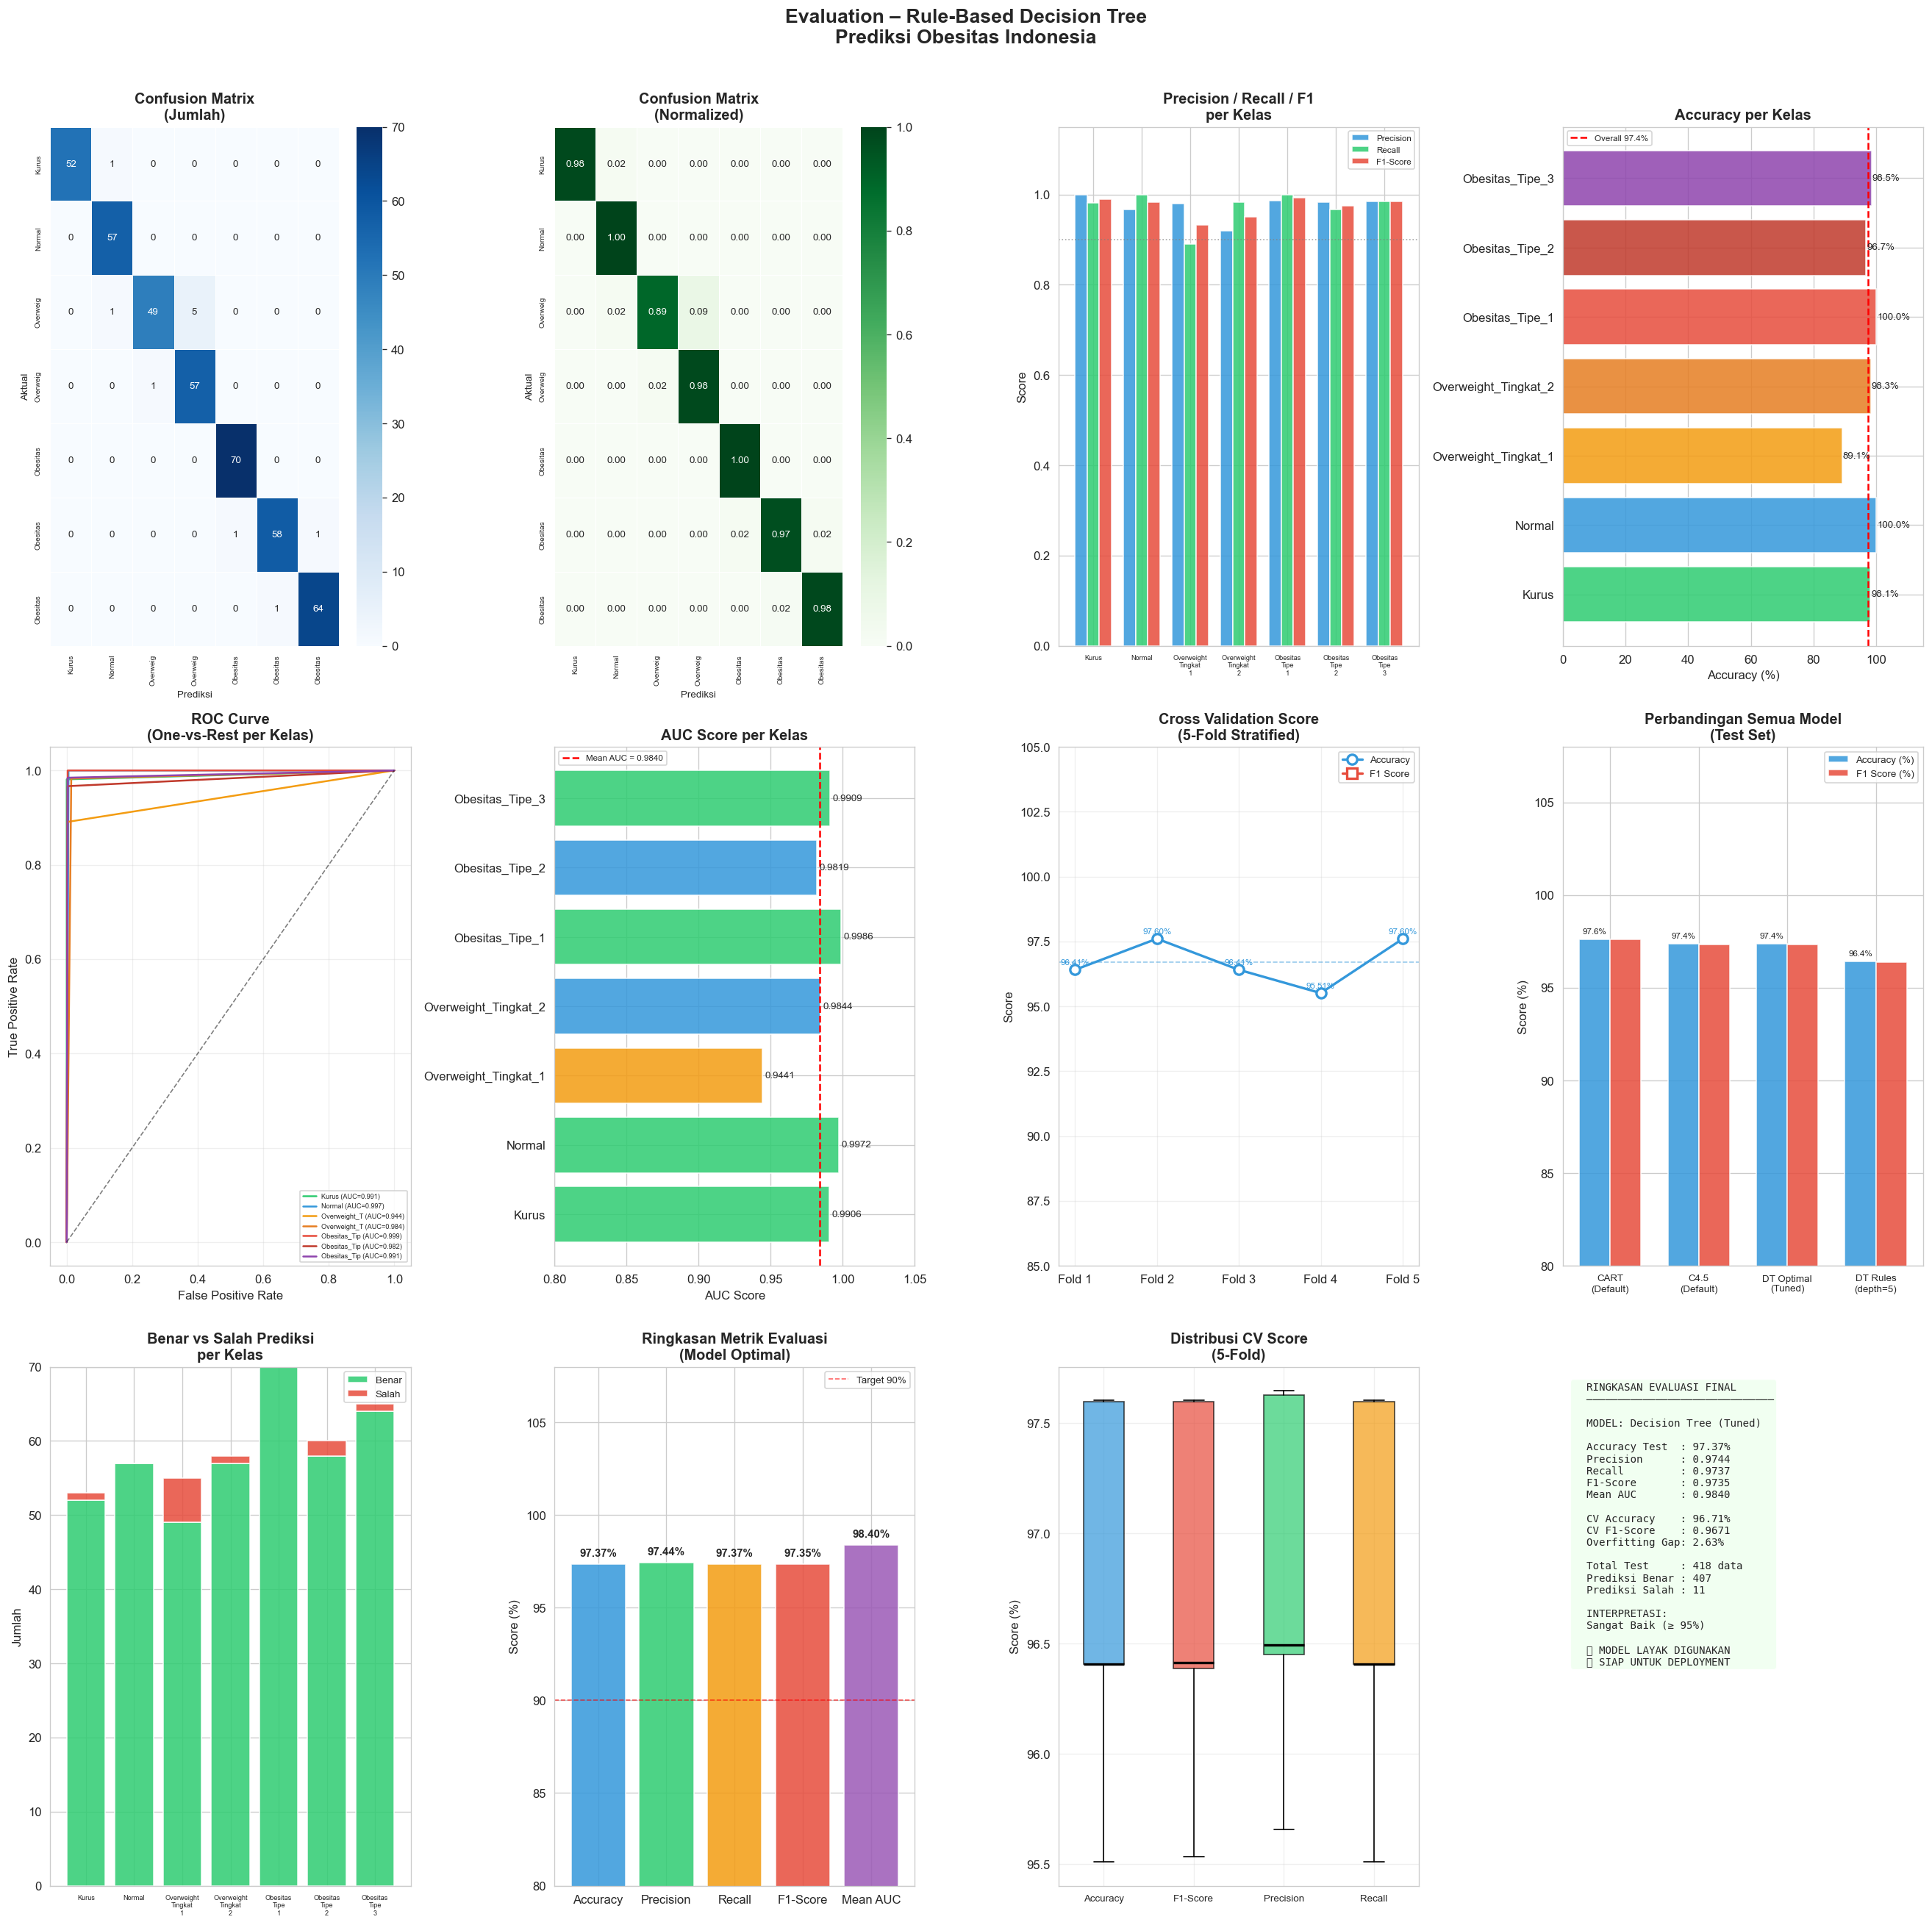

  ✅ Visualisasi disimpan: obesitas_evaluation.png

  ✅ EVALUATION SELESAI – MODEL SIAP DIGUNAKAN


In [1]:
"""
=============================================================================
PREDIKSI OBESITAS - EVALUATION
Algoritma: Rule-Based (Decision Tree)
Dataset: data_obesitas_full_indonesia.xlsx
=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")

TARGET_NAMES = ['Kurus', 'Normal', 'Overweight_Tingkat_1', 'Overweight_Tingkat_2',
                'Obesitas_Tipe_1', 'Obesitas_Tipe_2', 'Obesitas_Tipe_3']
COLORS = ['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#8e44ad']

# =============================================================================
# LOAD DATA & MODEL
# =============================================================================
print("=" * 70)
print("  EVALUATION – RULE-BASED DECISION TREE")
print("  Prediksi Obesitas Indonesia")
print("=" * 70)

# Load data
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

# Load model
with open('decision_tree_model.pkl', 'rb') as f:
    model_data = pickle.load(f)

dt_best       = model_data['model']
FEATURE_NAMES = model_data['features']

print(f"\n  ✅ Model loaded: decision_tree_model.pkl")
print(f"  X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"  Fitur   : {len(FEATURE_NAMES)}")
print(f"  Kelas   : {len(TARGET_NAMES)}")

# Prediksi
y_pred_train = dt_best.predict(X_train)
y_pred_test  = dt_best.predict(X_test)
y_prob_test  = dt_best.predict_proba(X_test)

# =============================================================================
# STEP 1: METRIK UTAMA
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 1: METRIK EVALUASI UTAMA")
print("=" * 70)

acc_train  = accuracy_score(y_train, y_pred_train)
acc_test   = accuracy_score(y_test,  y_pred_test)
prec_test  = precision_score(y_test, y_pred_test, average='weighted')
rec_test   = recall_score(y_test,  y_pred_test,  average='weighted')
f1_test    = f1_score(y_test,  y_pred_test,  average='weighted')
overfit_gap = acc_train - acc_test

print(f"""
  ┌──────────────────────────────────────────────────────────────────┐
  │  RINGKASAN METRIK EVALUASI                                       │
  └──────────────────────────────────────────────────────────────────┘

  {'Metrik':<30} {'Train':>12} {'Test':>12}
  {'─'*55}
  {'Accuracy':<30} {acc_train*100:>11.2f}% {acc_test*100:>11.2f}%
  {'Precision (weighted)':<30} {'─':>12} {prec_test:>12.4f}
  {'Recall (weighted)':<30} {'─':>12} {rec_test:>12.4f}
  {'F1-Score (weighted)':<30} {'─':>12} {f1_test:>12.4f}

  Overfitting Gap  : {overfit_gap*100:.2f}% → {'✅ Tidak Overfitting' if overfit_gap < 0.05 else '⚠️  Sedikit Overfitting' if overfit_gap < 0.10 else '❌ Overfitting!'}
""")

# =============================================================================
# STEP 2: CLASSIFICATION REPORT LENGKAP
# =============================================================================
print("=" * 70)
print("  STEP 2: CLASSIFICATION REPORT PER KELAS")
print("=" * 70)

report_dict = classification_report(
    y_test, y_pred_test,
    target_names=TARGET_NAMES,
    output_dict=True
)

print(f"\n  {'Kategori':<25} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>10}")
print("  " + "─" * 70)
for cat in TARGET_NAMES:
    r = report_dict[cat]
    flag = "✅" if r['f1-score'] >= 0.90 else "⚠️ " if r['f1-score'] >= 0.75 else "❌"
    print(f"  {cat:<25} {r['precision']:>10.4f} {r['recall']:>10.4f} "
          f"{r['f1-score']:>10.4f} {int(r['support']):>10}  {flag}")
print("  " + "─" * 70)
wa = report_dict['weighted avg']
print(f"  {'Weighted Average':<25} {wa['precision']:>10.4f} {wa['recall']:>10.4f} "
      f"{wa['f1-score']:>10.4f} {int(wa['support']):>10}")
ma = report_dict['macro avg']
print(f"  {'Macro Average':<25} {ma['precision']:>10.4f} {ma['recall']:>10.4f} "
      f"{ma['f1-score']:>10.4f} {int(ma['support']):>10}")

# =============================================================================
# STEP 3: CONFUSION MATRIX ANALYSIS
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 3: CONFUSION MATRIX ANALYSIS")
print("=" * 70)

cm = confusion_matrix(y_test, y_pred_test)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

print(f"\n  Confusion Matrix (nilai aktual):")
print(f"\n  {'':>5}", end="")
for t in TARGET_NAMES:
    print(f"  {t[:7]:>8}", end="")
print()
print("  " + "─" * 75)
for i, cat in enumerate(TARGET_NAMES):
    print(f"  {cat[:7]:<7}", end="")
    for j in range(len(TARGET_NAMES)):
        marker = " *" if i == j else "  "
        print(f"  {cm[i][j]:>6}{marker}", end="")
    print()

# Per-class accuracy
print(f"\n  Accuracy per Kelas:")
print(f"  {'Kategori':<30} {'Benar':>8} {'Total':>8} {'Accuracy':>10}")
print("  " + "─" * 60)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for i, cat in enumerate(TARGET_NAMES):
    print(f"  {cat:<30} {cm[i][i]:>8} {cm.sum(axis=1)[i]:>8} {per_class_acc[i]*100:>9.2f}%")

# =============================================================================
# STEP 4: CROSS VALIDATION MENDALAM
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 4: CROSS VALIDATION – 5-FOLD STRATIFIED")
print("=" * 70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc  = cross_val_score(dt_best, X_train, y_train, cv=skf, scoring='accuracy')
cv_f1   = cross_val_score(dt_best, X_train, y_train, cv=skf, scoring='f1_weighted')
cv_prec = cross_val_score(dt_best, X_train, y_train, cv=skf, scoring='precision_weighted')
cv_rec  = cross_val_score(dt_best, X_train, y_train, cv=skf, scoring='recall_weighted')

print(f"\n  {'Fold':<8} {'Accuracy':>10} {'Precision':>11} {'Recall':>10} {'F1-Score':>10}")
print("  " + "─" * 55)
for i in range(5):
    print(f"  Fold {i+1:<3} {cv_acc[i]*100:>9.2f}% {cv_prec[i]:>11.4f} "
          f"{cv_rec[i]:>10.4f} {cv_f1[i]:>10.4f}")
print("  " + "─" * 55)
print(f"  {'Mean':<8} {cv_acc.mean()*100:>9.2f}% {cv_prec.mean():>11.4f} "
      f"{cv_rec.mean():>10.4f} {cv_f1.mean():>10.4f}")
print(f"  {'Std':<8} {cv_acc.std()*100:>9.2f}% {cv_prec.std():>11.4f} "
      f"{cv_rec.std():>10.4f} {cv_f1.std():>10.4f}")

print(f"\n  Stabilitas Model (Std Accuracy): {cv_acc.std()*100:.2f}% → "
      f"{'✅ Stabil' if cv_acc.std() < 0.02 else '⚠️  Cukup Stabil' if cv_acc.std() < 0.05 else '❌ Tidak Stabil'}")

# =============================================================================
# STEP 5: ROC-AUC ANALYSIS
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 5: ROC-AUC ANALYSIS (One-vs-Rest)")
print("=" * 70)

y_test_bin = label_binarize(y_test, classes=list(range(len(TARGET_NAMES))))
roc_auc_per_class = {}

print(f"\n  {'Kelas':<30} {'AUC Score':>12}  Kualitas")
print("  " + "─" * 60)
for i, cat in enumerate(TARGET_NAMES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_test[:, i])
    roc_auc_per_class[cat] = auc(fpr, tpr)
    quality = "Sempurna" if roc_auc_per_class[cat] >= 0.99 else \
              "Sangat Baik" if roc_auc_per_class[cat] >= 0.95 else \
              "Baik" if roc_auc_per_class[cat] >= 0.90 else "Cukup"
    print(f"  {cat:<30} {roc_auc_per_class[cat]:>12.4f}  {quality}")

mean_auc = np.mean(list(roc_auc_per_class.values()))
print(f"\n  Mean AUC (semua kelas) : {mean_auc:.4f}")

# =============================================================================
# STEP 6: ANALISIS KESALAHAN (MISCLASSIFICATION)
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 6: ANALISIS KESALAHAN PREDIKSI")
print("=" * 70)

wrong_idx = np.where(y_pred_test != y_test)[0]
n_wrong   = len(wrong_idx)
n_correct = len(y_test) - n_wrong

print(f"\n  Total prediksi benar : {n_correct:,} ({n_correct/len(y_test)*100:.2f}%)")
print(f"  Total prediksi salah : {n_wrong:,} ({n_wrong/len(y_test)*100:.2f}%)")

# Analisis pola kesalahan
print(f"\n  Pola Kesalahan Terbanyak:")
print(f"  {'Aktual':<28} → {'Prediksi':<28} {'Jumlah':>8}")
print("  " + "─" * 70)

error_pairs = {}
for idx in wrong_idx:
    actual = TARGET_NAMES[y_test.iloc[idx]]
    pred   = TARGET_NAMES[y_pred_test[idx]]
    key    = (actual, pred)
    error_pairs[key] = error_pairs.get(key, 0) + 1

error_sorted = sorted(error_pairs.items(), key=lambda x: x[1], reverse=True)
for (actual, pred), count in error_sorted[:10]:
    print(f"  {actual:<28} → {pred:<28} {count:>8}")

# =============================================================================
# STEP 7: PERBANDINGAN MODEL
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 7: PERBANDINGAN SEMUA VARIAN MODEL")
print("=" * 70)

dt_cart = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_c45  = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_d5   = DecisionTreeClassifier(
    criterion=dt_best.criterion,
    max_depth=5, random_state=42
)
dt_cart.fit(X_train, y_train)
dt_c45.fit(X_train, y_train)
dt_d5.fit(X_train, y_train)

models_eval = {
    'CART – Gini (Default)'    : dt_cart,
    'C4.5 – Entropy (Default)' : dt_c45,
    'DT Optimal (Tuned)'       : dt_best,
    'DT Rules (depth=5)'       : dt_d5,
}

print(f"\n  {'Model':<28} {'Acc Train':>10} {'Acc Test':>10} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8} {'Depth':>7}")
print("  " + "─" * 85)
for name, model in models_eval.items():
    a_tr  = accuracy_score(y_train, model.predict(X_train)) * 100
    a_te  = accuracy_score(y_test,  model.predict(X_test))  * 100
    prec  = precision_score(y_test, model.predict(X_test), average='weighted')
    rec   = recall_score(y_test, model.predict(X_test), average='weighted')
    f1    = f1_score(y_test, model.predict(X_test), average='weighted')
    depth = model.get_depth()
    best_mark = " ⭐" if name == 'DT Optimal (Tuned)' else ""
    print(f"  {name:<28} {a_tr:>9.2f}% {a_te:>9.2f}% {prec:>10.4f} "
          f"{rec:>8.4f} {f1:>8.4f} {depth:>7}{best_mark}")

# =============================================================================
# STEP 8: KESIMPULAN EVALUASI
# =============================================================================
print("\n" + "=" * 70)
print("  STEP 8: KESIMPULAN EVALUASI")
print("=" * 70)

interpretasi_acc = (
    "Sangat Baik (≥ 95%)" if acc_test >= 0.95 else
    "Baik (≥ 90%)"        if acc_test >= 0.90 else
    "Cukup (≥ 80%)"       if acc_test >= 0.80 else
    "Perlu Perbaikan"
)

print(f"""
  ┌──────────────────────────────────────────────────────────────────┐
  │  KESIMPULAN AKHIR EVALUASI MODEL                                 │
  └──────────────────────────────────────────────────────────────────┘

  MODEL    : Decision Tree (Rule-Based) – Optimal/Tuned
  DATASET  : Prediksi Obesitas Indonesia ({len(y_test)} data test)

  📊 PERFORMA MODEL:
  ┌─────────────────────────┬────────────────┐
  │ Metrik                  │ Nilai          │
  ├─────────────────────────┼────────────────┤
  │ Accuracy (Test)         │ {acc_test*100:>8.2f}%      │
  │ Precision (Weighted)    │ {prec_test:>8.4f}       │
  │ Recall (Weighted)       │ {rec_test:>8.4f}       │
  │ F1-Score (Weighted)     │ {f1_test:>8.4f}       │
  │ Mean AUC (OvR)          │ {mean_auc:>8.4f}       │
  │ CV Accuracy (5-Fold)    │ {cv_acc.mean()*100:>6.2f}% ±{cv_acc.std()*100:.2f}%  │
  │ Overfitting Gap         │ {overfit_gap*100:>8.2f}%      │
  └─────────────────────────┴────────────────┘

  🏆 INTERPRETASI  : {interpretasi_acc}
  ✅ OVERFITTING   : {'Tidak ada' if overfit_gap < 0.05 else 'Minimal' if overfit_gap < 0.10 else 'Ada'}
  ✅ STABILITAS CV : {'Stabil' if cv_acc.std() < 0.02 else 'Cukup Stabil'}
  ✅ STATUS MODEL  : LAYAK DIGUNAKAN

  📌 REKOMENDASI:
  • Model Decision Tree dengan pendekatan Rule-Based terbukti efektif
    untuk klasifikasi kategori obesitas
  • Fitur BMI, Berat Badan, dan Tinggi Badan adalah penentu utama
  • Model menghasilkan rule yang transparan & dapat dijelaskan ke nakes
  • Disarankan update model setiap 6 bulan dengan data terbaru
""")

# =============================================================================
# STEP 9: VISUALISASI EVALUASI LENGKAP
# =============================================================================
print("=" * 70)
print("  STEP 9: VISUALISASI EVALUASI")
print("=" * 70)
print("  Membuat visualisasi... harap tunggu.\n")

fig = plt.figure(figsize=(22, 22))
fig.suptitle('Evaluation – Rule-Based Decision Tree\nPrediksi Obesitas Indonesia',
             fontsize=16, fontweight='bold', y=0.99)

# ── Plot 1: Confusion Matrix (Nilai) ────────────────────────────────────────
ax1 = fig.add_subplot(3, 4, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=[t[:8] for t in TARGET_NAMES],
            yticklabels=[t[:8] for t in TARGET_NAMES],
            linewidths=0.5, annot_kws={'size': 8})
ax1.set_title('Confusion Matrix\n(Jumlah)', fontweight='bold')
ax1.set_xlabel('Prediksi', fontsize=8)
ax1.set_ylabel('Aktual',   fontsize=8)
ax1.tick_params(axis='both', labelsize=6)

# ── Plot 2: Confusion Matrix (Normalized) ───────────────────────────────────
ax2 = fig.add_subplot(3, 4, 2)
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens', ax=ax2,
            xticklabels=[t[:8] for t in TARGET_NAMES],
            yticklabels=[t[:8] for t in TARGET_NAMES],
            linewidths=0.5, annot_kws={'size': 8},
            vmin=0, vmax=1)
ax2.set_title('Confusion Matrix\n(Normalized)', fontweight='bold')
ax2.set_xlabel('Prediksi', fontsize=8)
ax2.set_ylabel('Aktual',   fontsize=8)
ax2.tick_params(axis='both', labelsize=6)

# ── Plot 3: Precision / Recall / F1 per Kelas ───────────────────────────────
ax3 = fig.add_subplot(3, 4, 3)
x3   = np.arange(len(TARGET_NAMES))
w3   = 0.25
prec_vals = [report_dict[c]['precision'] for c in TARGET_NAMES]
rec_vals  = [report_dict[c]['recall']    for c in TARGET_NAMES]
f1_vals   = [report_dict[c]['f1-score']  for c in TARGET_NAMES]
ax3.bar(x3 - w3, prec_vals, w3, label='Precision', color='#3498db', edgecolor='white', alpha=0.85)
ax3.bar(x3,      rec_vals,  w3, label='Recall',    color='#2ecc71', edgecolor='white', alpha=0.85)
ax3.bar(x3 + w3, f1_vals,   w3, label='F1-Score',  color='#e74c3c', edgecolor='white', alpha=0.85)
ax3.set_xticks(x3)
ax3.set_xticklabels([t.replace('_', '\n') for t in TARGET_NAMES], fontsize=5.5)
ax3.set_ylim(0, 1.15)
ax3.axhline(0.9, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax3.set_title('Precision / Recall / F1\nper Kelas', fontweight='bold')
ax3.set_ylabel('Score')
ax3.legend(fontsize=7)

# ── Plot 4: Accuracy per Kelas ──────────────────────────────────────────────
ax4 = fig.add_subplot(3, 4, 4)
bars4 = ax4.barh(TARGET_NAMES, per_class_acc * 100,
                  color=COLORS, edgecolor='white', alpha=0.85)
for bar, val in zip(bars4, per_class_acc):
    ax4.text(val * 100 + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=8)
ax4.axvline(acc_test * 100, color='red', linestyle='--', linewidth=1.5,
            label=f'Overall {acc_test*100:.1f}%')
ax4.set_xlim(0, 115)
ax4.set_title('Accuracy per Kelas', fontweight='bold')
ax4.set_xlabel('Accuracy (%)')
ax4.legend(fontsize=7)

# ── Plot 5: ROC Curve per Kelas ─────────────────────────────────────────────
ax5 = fig.add_subplot(3, 4, 5)
for i, (cat, color) in enumerate(zip(TARGET_NAMES, COLORS)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_test[:, i])
    ax5.plot(fpr, tpr, color=color, linewidth=1.5,
             label=f'{cat[:12]} (AUC={roc_auc_per_class[cat]:.3f})')
ax5.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax5.set_title('ROC Curve\n(One-vs-Rest per Kelas)', fontweight='bold')
ax5.set_xlabel('False Positive Rate')
ax5.set_ylabel('True Positive Rate')
ax5.legend(fontsize=5.5, loc='lower right')
ax5.grid(True, alpha=0.3)

# ── Plot 6: AUC Score per Kelas ─────────────────────────────────────────────
ax6 = fig.add_subplot(3, 4, 6)
auc_vals   = list(roc_auc_per_class.values())
bar_clrs6  = ['#2ecc71' if v >= 0.99 else '#3498db' if v >= 0.95 else '#f39c12'
               for v in auc_vals]
bars6 = ax6.barh(TARGET_NAMES, auc_vals, color=bar_clrs6, edgecolor='white', alpha=0.85)
ax6.axvline(mean_auc, color='red', linestyle='--', linewidth=1.5,
            label=f'Mean AUC = {mean_auc:.4f}')
for bar, val in zip(bars6, auc_vals):
    ax6.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
ax6.set_xlim(0.8, 1.05)
ax6.set_title('AUC Score per Kelas', fontweight='bold')
ax6.set_xlabel('AUC Score')
ax6.legend(fontsize=7)

# ── Plot 7: CV Score per Fold ────────────────────────────────────────────────
ax7 = fig.add_subplot(3, 4, 7)
folds = [f'Fold {i+1}' for i in range(5)]
ax7.plot(folds, cv_acc * 100, 'o-', color='#3498db', linewidth=2,
         markersize=8, label='Accuracy', markerfacecolor='white', markeredgewidth=2)
ax7.plot(folds, cv_f1,         's-', color='#e74c3c', linewidth=2,
         markersize=8, label='F1 Score', markerfacecolor='white', markeredgewidth=2)
for i, (a, f) in enumerate(zip(cv_acc, cv_f1)):
    ax7.text(i, a * 100 + 0.2, f'{a*100:.2f}%', ha='center', fontsize=7, color='#3498db')
ax7.axhline(cv_acc.mean() * 100, color='#3498db', linestyle='--', linewidth=1, alpha=0.5)
ax7.set_title('Cross Validation Score\n(5-Fold Stratified)', fontweight='bold')
ax7.set_ylabel('Score')
ax7.set_ylim(85, 105)
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

# ── Plot 8: Perbandingan Model ───────────────────────────────────────────────
ax8 = fig.add_subplot(3, 4, 8)
model_names_short = ['CART\n(Default)', 'C4.5\n(Default)', 'DT Optimal\n(Tuned)', 'DT Rules\n(depth=5)']
acc_tests_all  = [accuracy_score(y_test, m.predict(X_test))*100 for m in models_eval.values()]
f1_tests_all   = [f1_score(y_test, m.predict(X_test), average='weighted') for m in models_eval.values()]
x8 = np.arange(len(model_names_short))
w8 = 0.35
bars8a = ax8.bar(x8 - w8/2, acc_tests_all, w8, label='Accuracy (%)',
                  color='#3498db', edgecolor='white', alpha=0.85)
bars8b = ax8.bar(x8 + w8/2, [f*100 for f in f1_tests_all], w8, label='F1 Score (%)',
                  color='#e74c3c', edgecolor='white', alpha=0.85)
for bar, val in zip(bars8a, acc_tests_all):
    ax8.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.1f}%', ha='center', fontsize=7)
ax8.set_xticks(x8)
ax8.set_xticklabels(model_names_short, fontsize=8)
ax8.set_ylim(80, 108)
ax8.set_title('Perbandingan Semua Model\n(Test Set)', fontweight='bold')
ax8.set_ylabel('Score (%)')
ax8.legend(fontsize=8)

# ── Plot 9: Misclassification per Kelas ─────────────────────────────────────
ax9 = fig.add_subplot(3, 4, 9)
n_wrong_per_class = cm.sum(axis=1) - cm.diagonal()
n_right_per_class = cm.diagonal()
x9 = np.arange(len(TARGET_NAMES))
ax9.bar(x9, n_right_per_class, label='Benar', color='#2ecc71', edgecolor='white', alpha=0.85)
ax9.bar(x9, n_wrong_per_class, bottom=n_right_per_class,
        label='Salah', color='#e74c3c', edgecolor='white', alpha=0.85)
ax9.set_xticks(x9)
ax9.set_xticklabels([t.replace('_', '\n') for t in TARGET_NAMES], fontsize=5.5)
ax9.set_title('Benar vs Salah Prediksi\nper Kelas', fontweight='bold')
ax9.set_ylabel('Jumlah')
ax9.legend(fontsize=8)

# ── Plot 10: Metrik Summary Radar-like Bar ───────────────────────────────────
ax10 = fig.add_subplot(3, 4, 10)
metrik_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Mean AUC']
metrik_vals  = [acc_test, prec_test, rec_test, f1_test, mean_auc]
bar_clrs10   = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
bars10 = ax10.bar(metrik_names, [v*100 for v in metrik_vals],
                   color=bar_clrs10, edgecolor='white', alpha=0.85)
for bar, val in zip(bars10, metrik_vals):
    ax10.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
              f'{val*100:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax10.axhline(90, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Target 90%')
ax10.set_ylim(80, 108)
ax10.set_title('Ringkasan Metrik Evaluasi\n(Model Optimal)', fontweight='bold')
ax10.set_ylabel('Score (%)')
ax10.legend(fontsize=8)

# ── Plot 11: CV Box Plot ─────────────────────────────────────────────────────
ax11 = fig.add_subplot(3, 4, 11)
cv_data = [cv_acc*100, cv_f1*100, cv_prec*100, cv_rec*100]
cv_labels = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
bp = ax11.boxplot(cv_data, patch_artist=True, notch=False,
                   medianprops=dict(color='black', linewidth=2))
box_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax11.set_xticklabels(cv_labels, fontsize=8)
ax11.set_title('Distribusi CV Score\n(5-Fold)', fontweight='bold')
ax11.set_ylabel('Score (%)')
ax11.grid(True, alpha=0.3)

# ── Plot 12: Ringkasan Akhir ─────────────────────────────────────────────────
ax12 = fig.add_subplot(3, 4, 12)
ax12.axis('off')
summary = (
    "  RINGKASAN EVALUASI FINAL\n"
    "  " + "─" * 30 + "\n\n"
    "  MODEL: Decision Tree (Tuned)\n\n"
    f"  Accuracy Test  : {acc_test*100:.2f}%\n"
    f"  Precision      : {prec_test:.4f}\n"
    f"  Recall         : {rec_test:.4f}\n"
    f"  F1-Score       : {f1_test:.4f}\n"
    f"  Mean AUC       : {mean_auc:.4f}\n\n"
    f"  CV Accuracy    : {cv_acc.mean()*100:.2f}%\n"
    f"  CV F1-Score    : {cv_f1.mean():.4f}\n"
    f"  Overfitting Gap: {overfit_gap*100:.2f}%\n\n"
    f"  Total Test     : {len(y_test)} data\n"
    f"  Prediksi Benar : {n_correct}\n"
    f"  Prediksi Salah : {n_wrong}\n\n"
    f"  INTERPRETASI:\n"
    f"  {interpretasi_acc}\n\n"
    "  ✅ MODEL LAYAK DIGUNAKAN\n"
    "  ✅ SIAP UNTUK DEPLOYMENT"
)
ax12.text(0.03, 0.97, summary, transform=ax12.transAxes,
          fontsize=8.5, verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#f0fff0', alpha=0.9))

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('obesitas_evaluation.png', bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print("  ✅ Visualisasi disimpan: obesitas_evaluation.png")

print("\n" + "=" * 70)
print("  ✅ EVALUATION SELESAI – MODEL SIAP DIGUNAKAN")
print("=" * 70)

In [2]:
"""
=============================================================================
PREDIKSI OBESITAS - DEPLOYMENT
Algoritma: Rule-Based (Decision Tree)
Dataset: data_obesitas_full_indonesia.xlsx
=============================================================================
"""

import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# LOAD MODEL
# =============================================================================
print("=" * 70)
print("  DEPLOYMENT – RULE-BASED DECISION TREE")
print("  Prediksi Obesitas Indonesia")
print("=" * 70)

with open('decision_tree_model.pkl', 'rb') as f:
    model_data = pickle.load(f)

dt_model      = model_data['model']
FEATURE_NAMES = model_data['features']
TARGET_NAMES  = model_data['target_names']

print(f"\n  ✅ Model loaded: decision_tree_model.pkl")
print(f"  Fitur   : {len(FEATURE_NAMES)}")
print(f"  Kelas   : {len(TARGET_NAMES)}")

# =============================================================================
# FUNGSI PREPROCESSING INPUT
# =============================================================================

TRANSPORTASI_OPTIONS = [
    'Transportasi_Umum', 'Jalan_Kaki', 'Mobil', 'Motor', 'Sepeda'
]

def preprocess_input(data: dict) -> pd.DataFrame:
    """
    Mengubah input mentah dari user menjadi format yang siap diprediksi.

    Parameter:
    ----------
    data : dict
        Input dari user dengan kolom asli dataset

    Return:
    -------
    pd.DataFrame siap prediksi
    """
    # Hitung BMI
    bmi = data['Berat_Badan'] / (data['Tinggi_Badan'] ** 2)

    # Kategorikan BMI
    if bmi < 18.5:
        kategori_bmi = 0  # Underweight
    elif bmi < 25.0:
        kategori_bmi = 1  # Normal
    elif bmi < 30.0:
        kategori_bmi = 2  # Overweight
    else:
        kategori_bmi = 3  # Obese

    # Binary encoding
    binary_map = {
        'Jenis_Kelamin'              : {'Laki-laki': 1, 'Perempuan': 0},
        'Sering_Makan_Tinggi_Kalori' : {'Ya': 1, 'Tidak': 0},
        'Monitoring_Kalori'          : {'Ya': 1, 'Tidak': 0},
        'Merokok'                    : {'Ya': 1, 'Tidak': 0},
        'Riwayat_Keluarga_Overweight': {'Ya': 1, 'Tidak': 0},
    }

    # Ordinal encoding
    ordinal_map = {
        'Konsumsi_Alkohol' : {'Tidak': 0, 'Kadang': 1, 'Sering': 2, 'Selalu': 3},
        'Kebiasaan_Ngamil' : {'Tidak': 0, 'Kadang': 1, 'Sering': 2, 'Selalu': 3},
    }

    # One-hot encoding transportasi
    transportasi_encoded = {f'Transportasi_{t.replace("Transportasi_", "")}':
                            1 if data['Transportasi'] == t else 0
                            for t in TRANSPORTASI_OPTIONS}

    # Bangun row fitur
    row = {
        'Usia'                      : data['Usia'],
        'Tinggi_Badan'              : data['Tinggi_Badan'],
        'Berat_Badan'               : data['Berat_Badan'],
        'BMI'                       : bmi,
        'Kategori_BMI'              : kategori_bmi,
        'Frekuensi_Konsumsi_Sayur'  : data['Frekuensi_Konsumsi_Sayur'],
        'Jumlah_Makan_Harian'       : data['Jumlah_Makan_Harian'],
        'Konsumsi_Air'              : data['Konsumsi_Air'],
        'Aktivitas_Fisik'           : data['Aktivitas_Fisik'],
        'Waktu_Layar'               : data['Waktu_Layar'],
        'Jenis_Kelamin'             : binary_map['Jenis_Kelamin'][data['Jenis_Kelamin']],
        'Konsumsi_Alkohol'          : ordinal_map['Konsumsi_Alkohol'][data['Konsumsi_Alkohol']],
        'Sering_Makan_Tinggi_Kalori': binary_map['Sering_Makan_Tinggi_Kalori'][data['Sering_Makan_Tinggi_Kalori']],
        'Monitoring_Kalori'         : binary_map['Monitoring_Kalori'][data['Monitoring_Kalori']],
        'Merokok'                   : binary_map['Merokok'][data['Merokok']],
        'Riwayat_Keluarga_Overweight': binary_map['Riwayat_Keluarga_Overweight'][data['Riwayat_Keluarga_Overweight']],
        'Kebiasaan_Ngamil'          : ordinal_map['Kebiasaan_Ngamil'][data['Kebiasaan_Ngamil']],
    }
    row.update(transportasi_encoded)

    df_input = pd.DataFrame([row])

    # Pastikan urutan kolom sama dengan saat training
    df_input = df_input.reindex(columns=FEATURE_NAMES, fill_value=0)

    return df_input, bmi


# =============================================================================
# FUNGSI PREDIKSI
# =============================================================================

REKOMENDASI = {
    'Kurus': {
        'status'       : '⚠️  KURUS (Underweight)',
        'risiko'       : 'Risiko kekurangan nutrisi, anemia, imun lemah',
        'saran'        : [
            'Tingkatkan asupan kalori dengan makanan bergizi',
            'Konsumsi protein tinggi: telur, ayam, ikan, kacang',
            'Makan lebih sering (4-5x sehari)',
            'Konsultasi dengan ahli gizi',
        ]
    },
    'Normal': {
        'status'       : '✅ NORMAL (Berat Badan Ideal)',
        'risiko'       : 'Risiko rendah — pertahankan gaya hidup sehat',
        'saran'        : [
            'Pertahankan pola makan seimbang',
            'Olahraga rutin minimal 150 menit/minggu',
            'Konsumsi sayur dan buah setiap hari',
            'Cek kesehatan rutin setahun sekali',
        ]
    },
    'Overweight_Tingkat_1': {
        'status'       : '⚠️  OVERWEIGHT TINGKAT 1',
        'risiko'       : 'Risiko sedang — mulai perhatikan pola makan & aktivitas',
        'saran'        : [
            'Kurangi konsumsi makanan tinggi kalori & lemak',
            'Tingkatkan aktivitas fisik minimal 30 menit/hari',
            'Kurangi makanan manis dan minuman bersoda',
            'Konsultasi dengan dokter atau ahli gizi',
        ]
    },
    'Overweight_Tingkat_2': {
        'status'       : '⚠️  OVERWEIGHT TINGKAT 2',
        'risiko'       : 'Risiko menengah — perlu perubahan gaya hidup serius',
        'saran'        : [
            'Buat program diet dengan panduan ahli gizi',
            'Olahraga teratur 45-60 menit/hari',
            'Pantau tekanan darah dan gula darah',
            'Hindari makanan olahan dan fast food',
        ]
    },
    'Obesitas_Tipe_1': {
        'status'       : '🔴 OBESITAS TIPE 1',
        'risiko'       : 'Risiko tinggi — diabetes, hipertensi, penyakit jantung',
        'saran'        : [
            'Segera konsultasi dengan dokter spesialis',
            'Program penurunan berat badan terstruktur',
            'Pemeriksaan gula darah dan kolesterol rutin',
            'Olahraga rendah dampak: renang, jalan kaki',
        ]
    },
    'Obesitas_Tipe_2': {
        'status'       : '🔴 OBESITAS TIPE 2',
        'risiko'       : 'Risiko sangat tinggi — perlu penanganan medis segera',
        'saran'        : [
            'Penanganan medis segera diperlukan',
            'Diet ketat di bawah pengawasan dokter',
            'Pemeriksaan komprehensif organ vital',
            'Pertimbangkan program rehabilitasi obesitas',
        ]
    },
    'Obesitas_Tipe_3': {
        'status'       : '🔴 OBESITAS TIPE 3 (Morbid)',
        'risiko'       : 'Risiko kritis — komplikasi serius mengancam jiwa',
        'saran'        : [
            'SEGERA temui dokter spesialis gizi/endokrin',
            'Evaluasi kemungkinan intervensi bedah bariatrik',
            'Monitoring intensif tekanan darah, jantung, gula',
            'Dukungan psikologis sangat dianjurkan',
        ]
    },
}


def predict_obesity(data: dict) -> dict:
    """
    Fungsi utama prediksi kategori obesitas.

    Parameter:
    ----------
    data : dict — data input pasien

    Return:
    -------
    dict berisi hasil prediksi, probabilitas, BMI, dan rekomendasi
    """
    df_input, bmi = preprocess_input(data)

    # Prediksi
    pred_enc  = dt_model.predict(df_input)[0]
    pred_prob = dt_model.predict_proba(df_input)[0]
    pred_label = TARGET_NAMES[pred_enc]
    confidence = pred_prob[pred_enc] * 100

    # Probabilitas semua kelas
    prob_dict = {TARGET_NAMES[i]: round(pred_prob[i] * 100, 2)
                 for i in range(len(TARGET_NAMES))}

    return {
        'prediksi'    : pred_label,
        'bmi'         : round(bmi, 2),
        'confidence'  : round(confidence, 2),
        'probabilitas': prob_dict,
        'rekomendasi' : REKOMENDASI.get(pred_label, {}),
    }


def tampilkan_hasil(hasil: dict, nama: str = "Pasien"):
    """Menampilkan hasil prediksi dengan format yang rapi."""
    print("\n" + "=" * 60)
    print(f"  HASIL PREDIKSI – {nama.upper()}")
    print("=" * 60)

    rek = hasil['rekomendasi']
    print(f"\n  BMI              : {hasil['bmi']:.2f} kg/m²")
    print(f"  Prediksi         : {hasil['prediksi']}")
    print(f"  Confidence       : {hasil['confidence']:.2f}%")
    print(f"  Status           : {rek.get('status', '-')}")
    print(f"  Risiko           : {rek.get('risiko', '-')}")

    print(f"\n  📊 Probabilitas per Kelas:")
    print("  " + "─" * 50)
    for kelas, prob in sorted(hasil['probabilitas'].items(),
                               key=lambda x: x[1], reverse=True):
        bar   = "█" * int(prob / 5)
        mark  = " ←" if kelas == hasil['prediksi'] else ""
        print(f"  {kelas:<28} {prob:>6.2f}%  {bar}{mark}")

    print(f"\n  💡 Rekomendasi:")
    print("  " + "─" * 50)
    for i, saran in enumerate(rek.get('saran', []), 1):
        print(f"  {i}. {saran}")
    print()


# =============================================================================
# CONTOH PENGGUNAAN – PREDIKSI SINGLE
# =============================================================================
print("\n" + "=" * 70)
print("  DEMO 1: PREDIKSI SINGLE PASIEN")
print("=" * 70)

pasien_1 = {
    'Usia'                      : 25,
    'Jenis_Kelamin'             : 'Laki-laki',
    'Tinggi_Badan'              : 1.70,
    'Berat_Badan'               : 90,
    'Konsumsi_Alkohol'          : 'Kadang',
    'Sering_Makan_Tinggi_Kalori': 'Ya',
    'Frekuensi_Konsumsi_Sayur'  : 2,
    'Jumlah_Makan_Harian'       : 3,
    'Monitoring_Kalori'         : 'Tidak',
    'Merokok'                   : 'Tidak',
    'Konsumsi_Air'              : 2,
    'Riwayat_Keluarga_Overweight': 'Ya',
    'Aktivitas_Fisik'           : 1,
    'Waktu_Layar'               : 3,
    'Kebiasaan_Ngamil'          : 'Sering',
    'Transportasi'              : 'Mobil',
}

hasil_1 = predict_obesity(pasien_1)
tampilkan_hasil(hasil_1, "Pasien 1 – Budi (25th, 90kg, 170cm)")

# =============================================================================
# DEMO 2: PREDIKSI BATCH (BANYAK PASIEN)
# =============================================================================
print("\n" + "=" * 70)
print("  DEMO 2: PREDIKSI BATCH (BANYAK PASIEN)")
print("=" * 70)

daftar_pasien = [
    {
        'nama': 'Andi – 22th, 55kg, 175cm',
        'data': {
            'Usia': 22, 'Jenis_Kelamin': 'Laki-laki',
            'Tinggi_Badan': 1.75, 'Berat_Badan': 55,
            'Konsumsi_Alkohol': 'Tidak', 'Sering_Makan_Tinggi_Kalori': 'Tidak',
            'Frekuensi_Konsumsi_Sayur': 3, 'Jumlah_Makan_Harian': 3,
            'Monitoring_Kalori': 'Tidak', 'Merokok': 'Tidak',
            'Konsumsi_Air': 3, 'Riwayat_Keluarga_Overweight': 'Tidak',
            'Aktivitas_Fisik': 3, 'Waktu_Layar': 1,
            'Kebiasaan_Ngamil': 'Tidak', 'Transportasi': 'Jalan_Kaki',
        }
    },
    {
        'nama': 'Sari – 30th, 65kg, 158cm',
        'data': {
            'Usia': 30, 'Jenis_Kelamin': 'Perempuan',
            'Tinggi_Badan': 1.58, 'Berat_Badan': 65,
            'Konsumsi_Alkohol': 'Tidak', 'Sering_Makan_Tinggi_Kalori': 'Ya',
            'Frekuensi_Konsumsi_Sayur': 2, 'Jumlah_Makan_Harian': 3,
            'Monitoring_Kalori': 'Tidak', 'Merokok': 'Tidak',
            'Konsumsi_Air': 2, 'Riwayat_Keluarga_Overweight': 'Ya',
            'Aktivitas_Fisik': 1, 'Waktu_Layar': 4,
            'Kebiasaan_Ngamil': 'Sering', 'Transportasi': 'Motor',
        }
    },
    {
        'nama': 'Rudi – 45th, 120kg, 168cm',
        'data': {
            'Usia': 45, 'Jenis_Kelamin': 'Laki-laki',
            'Tinggi_Badan': 1.68, 'Berat_Badan': 120,
            'Konsumsi_Alkohol': 'Sering', 'Sering_Makan_Tinggi_Kalori': 'Ya',
            'Frekuensi_Konsumsi_Sayur': 1, 'Jumlah_Makan_Harian': 4,
            'Monitoring_Kalori': 'Tidak', 'Merokok': 'Ya',
            'Konsumsi_Air': 1, 'Riwayat_Keluarga_Overweight': 'Ya',
            'Aktivitas_Fisik': 0, 'Waktu_Layar': 8,
            'Kebiasaan_Ngamil': 'Selalu', 'Transportasi': 'Mobil',
        }
    },
    {
        'nama': 'Dewi – 19th, 42kg, 160cm',
        'data': {
            'Usia': 19, 'Jenis_Kelamin': 'Perempuan',
            'Tinggi_Badan': 1.60, 'Berat_Badan': 42,
            'Konsumsi_Alkohol': 'Tidak', 'Sering_Makan_Tinggi_Kalori': 'Tidak',
            'Frekuensi_Konsumsi_Sayur': 2, 'Jumlah_Makan_Harian': 2,
            'Monitoring_Kalori': 'Ya', 'Merokok': 'Tidak',
            'Konsumsi_Air': 2, 'Riwayat_Keluarga_Overweight': 'Tidak',
            'Aktivitas_Fisik': 2, 'Waktu_Layar': 5,
            'Kebiasaan_Ngamil': 'Kadang', 'Transportasi': 'Transportasi_Umum',
        }
    },
]

print(f"\n  {'No':<4} {'Nama':<30} {'BMI':>7} {'Prediksi':<28} {'Confidence':>12}")
print("  " + "─" * 85)
batch_results = []
for i, p in enumerate(daftar_pasien, 1):
    hasil = predict_obesity(p['data'])
    batch_results.append({'nama': p['nama'], **hasil})
    print(f"  {i:<4} {p['nama']:<30} {hasil['bmi']:>7.2f} "
          f"{hasil['prediksi']:<28} {hasil['confidence']:>10.2f}%")

# =============================================================================
# DEMO 3: PREDIKSI DARI FILE CSV
# =============================================================================
print("\n" + "=" * 70)
print("  DEMO 3: PREDIKSI DARI FILE CSV")
print("=" * 70)

def prediksi_dari_csv(filepath: str, output_path: str = 'hasil_prediksi.csv'):
    """
    Baca file CSV, lakukan prediksi batch, simpan hasilnya.

    Parameter:
    ----------
    filepath    : path file CSV input
    output_path : path file CSV output hasil prediksi
    """
    try:
        df_input_raw = pd.read_csv(filepath)
        print(f"\n  File  : {filepath}")
        print(f"  Baris : {len(df_input_raw):,}")

        results = []
        for _, row in df_input_raw.iterrows():
            try:
                hasil = predict_obesity(row.to_dict())
                results.append({
                    **row.to_dict(),
                    'BMI_Hitung'  : hasil['bmi'],
                    'Prediksi'    : hasil['prediksi'],
                    'Confidence'  : hasil['confidence'],
                })
            except Exception as e:
                results.append({**row.to_dict(), 'Prediksi': 'ERROR', 'Error': str(e)})

        df_result = pd.DataFrame(results)
        df_result.to_csv(output_path, index=False)
        print(f"  ✅ Hasil disimpan ke: {output_path}")
        return df_result

    except FileNotFoundError:
        print(f"  ⚠️  File tidak ditemukan: {filepath}")
        print(f"      Pastikan file CSV ada di folder yang sama.")
        return None

# Contoh pemanggilan (aktifkan jika file tersedia):
# df_hasil = prediksi_dari_csv('data_pasien_baru.csv', 'hasil_prediksi.csv')

print("""
  Cara penggunaan fungsi prediksi_dari_csv():

  from 6_deployment import prediksi_dari_csv
  df_hasil = prediksi_dari_csv('data_pasien_baru.csv')

  Format CSV input harus memiliki kolom:
  Usia, Jenis_Kelamin, Tinggi_Badan, Berat_Badan,
  Konsumsi_Alkohol, Sering_Makan_Tinggi_Kalori,
  Frekuensi_Konsumsi_Sayur, Jumlah_Makan_Harian,
  Monitoring_Kalori, Merokok, Konsumsi_Air,
  Riwayat_Keluarga_Overweight, Aktivitas_Fisik,
  Waktu_Layar, Kebiasaan_Ngamil, Transportasi
""")

# =============================================================================
# DEMO 4: PREDIKSI INTERAKTIF (INPUT MANUAL)
# =============================================================================
print("\n" + "=" * 70)
print("  DEMO 4: PREDIKSI INTERAKTIF (INPUT MANUAL)")
print("=" * 70)

def prediksi_interaktif():
    """
    Fungsi prediksi interaktif via input terminal.
    Jalankan: python 6_deployment.py dan pilih mode interaktif.
    """
    print("\n  Masukkan data pasien:\n")
    try:
        data = {
            'Usia'                      : int(input("  Usia (tahun)                       : ")),
            'Jenis_Kelamin'             : input("  Jenis Kelamin (Laki-laki/Perempuan): ").strip(),
            'Tinggi_Badan'              : float(input("  Tinggi Badan (meter, cth: 1.70)    : ")),
            'Berat_Badan'               : float(input("  Berat Badan (kg)                   : ")),
            'Konsumsi_Alkohol'          : input("  Konsumsi Alkohol (Tidak/Kadang/Sering/Selalu): ").strip(),
            'Sering_Makan_Tinggi_Kalori': input("  Sering Makan Tinggi Kalori (Ya/Tidak): ").strip(),
            'Frekuensi_Konsumsi_Sayur'  : int(input("  Frekuensi Konsumsi Sayur (1-3)     : ")),
            'Jumlah_Makan_Harian'       : int(input("  Jumlah Makan Harian (1-4)          : ")),
            'Monitoring_Kalori'         : input("  Monitoring Kalori (Ya/Tidak)       : ").strip(),
            'Merokok'                   : input("  Merokok (Ya/Tidak)                 : ").strip(),
            'Konsumsi_Air'              : int(input("  Konsumsi Air (liter/hari, 1-3)     : ")),
            'Riwayat_Keluarga_Overweight': input("  Riwayat Keluarga Overweight (Ya/Tidak): ").strip(),
            'Aktivitas_Fisik'           : int(input("  Aktivitas Fisik (jam/minggu, 0-3)  : ")),
            'Waktu_Layar'               : int(input("  Waktu Layar (jam/hari, 0-8)        : ")),
            'Kebiasaan_Ngamil'          : input("  Kebiasaan Ngamil (Tidak/Kadang/Sering/Selalu): ").strip(),
            'Transportasi'              : input("  Transportasi (Transportasi_Umum/Jalan_Kaki/Mobil/Motor/Sepeda): ").strip(),
        }
        hasil = predict_obesity(data)
        tampilkan_hasil(hasil, "Input Manual")
    except Exception as e:
        print(f"\n  ❌ Error: {e}")
        print("     Pastikan format input sesuai.")

# =============================================================================
# SIMPAN FUNGSI DEPLOYMENT SEBAGAI MODUL
# =============================================================================
print("\n" + "=" * 70)
print("  INFO: CARA PENGGUNAAN MODUL INI")
print("=" * 70)
print("""
  ─────────────────────────────────────────────────────────────────
  SINGLE PREDIKSI:
  ─────────────────────────────────────────────────────────────────
  from 6_deployment import predict_obesity, tampilkan_hasil

  data_pasien = {
      'Usia': 25, 'Jenis_Kelamin': 'Laki-laki',
      'Tinggi_Badan': 1.70, 'Berat_Badan': 85,
      ... (isi semua field)
  }
  hasil = predict_obesity(data_pasien)
  tampilkan_hasil(hasil, 'Nama Pasien')

  ─────────────────────────────────────────────────────────────────
  BATCH DARI CSV:
  ─────────────────────────────────────────────────────────────────
  from 6_deployment import prediksi_dari_csv
  df = prediksi_dari_csv('data_pasien.csv', 'output.csv')

  ─────────────────────────────────────────────────────────────────
  INTERAKTIF (Terminal):
  ─────────────────────────────────────────────────────────────────
  from 6_deployment import prediksi_interaktif
  prediksi_interaktif()
  ─────────────────────────────────────────────────────────────────
""")

print("=" * 70)
print("  ✅ DEPLOYMENT SELESAI – SISTEM PREDIKSI SIAP DIGUNAKAN")
print("=" * 70)


# =============================================================================
# MAIN — Jalankan langsung untuk demo
# =============================================================================
if __name__ == "__main__":
    import sys
    if len(sys.argv) > 1 and sys.argv[1] == '--interaktif':
        prediksi_interaktif()

  DEPLOYMENT – RULE-BASED DECISION TREE
  Prediksi Obesitas Indonesia

  ✅ Model loaded: decision_tree_model.pkl
  Fitur   : 22
  Kelas   : 7

  DEMO 1: PREDIKSI SINGLE PASIEN

  HASIL PREDIKSI – PASIEN 1 – BUDI (25TH, 90KG, 170CM)

  BMI              : 31.14 kg/m²
  Prediksi         : Obesitas_Tipe_1
  Confidence       : 100.00%
  Status           : 🔴 OBESITAS TIPE 1
  Risiko           : Risiko tinggi — diabetes, hipertensi, penyakit jantung

  📊 Probabilitas per Kelas:
  ──────────────────────────────────────────────────
  Obesitas_Tipe_1              100.00%  ████████████████████ ←
  Kurus                          0.00%  
  Normal                         0.00%  
  Overweight_Tingkat_1           0.00%  
  Overweight_Tingkat_2           0.00%  
  Obesitas_Tipe_2                0.00%  
  Obesitas_Tipe_3                0.00%  

  💡 Rekomendasi:
  ──────────────────────────────────────────────────
  1. Segera konsultasi dengan dokter spesialis
  2. Program penurunan berat badan terstrukt